# 공모전 주제 내용

- 제공된 다양한 데이터를 활용해 우리 주변의 영세/중소 가맹점이 갑자기 어려워지는 순간(매출 급락, 폐업 위험 등)을
미리 감지할 수 있는

'**AI 조기 경보 시스템**' 제안
- 모델 개발뿐 아니라, 데이터에서 **어떤 신호가 위기를 미리 알려주는지 직접 찾아내고**,

이 결과를 실제로 소상공인이
쉽게 **활용할 수 있는 아이디어도 함께 제안**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


import folium
from geopy.geocoders import Nominatim
import time
import matplotlib
import matplotlib.cm as cm
from pathlib import Path


In [6]:
# 한글 깨짐 해결
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [7]:
plt.rc('font', family='NanumBarunGothic')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

## 파일 로드 및 한글컬럼명으로 변경

In [ ]:
# 현재 노트북 위치
BASE_DIR = Path().resolve()

# 프로젝트 루트 (notebooks의 상위 폴더)
PROJECT_ROOT = BASE_DIR.parent

# data 폴더
DATA_DIR = PROJECT_ROOT / "data"


path1 = DATA_DIR / "big_data_set1_f.csv"
path2 = DATA_DIR / "big_data_set2_f.csv"
path3 = DATA_DIR / "big_data_set3_f.csv"


store_info = pd.read_csv(path1, encoding='cp949')
store_sales = pd.read_csv(path2, encoding='cp949')
store_customer = pd.read_csv(path3, encoding='cp949')


In [ ]:
# 데이터셋1 로드 (파일명은 실제 파일명으로 수정)
# df1 = pd.read_csv('your_dataset1_file.csv')

# 컬럼명 변경
store_info = store_info.rename(columns={
    'ENCODED_MCT': '가맹점구분번호',
    'MCT_BSE_AR': '가맹점주소',
    'MCT_NM': '가맹점명',
    'MCT_BRD_NUM': '브랜드구분코드',
    'MCT_SIGUNGU_NM': '가맹점지역',
    'HPSN_MCT_ZCD_NM': '업종',
    'HPSN_MCT_BZN_CD_NM': '상권',
    'ARE_D': '개설일',
    'MCT_ME_D': '폐업일'
})

# 데이터셋2 로드 (파일명은 실제 파일명으로 수정)
# df2 = pd.read_csv('your_dataset2_file.csv')

# 컬럼명 변경
store_sales = store_sales.rename(columns={
    'ENCODED_MCT': '가맹점구분번호',
    'TA_YM': '기준년월',
    'MCT_OPE_MS_CN': '가맹점 운영개월수 구간',
    'RC_M1_SAA': '매출금액 구간',
    'RC_M1_TO_UE_CT': '매출건수 구간',
    'RC_M1_UE_CUS_CN': '유니크 고객 수 구간',
    'RC_M1_AV_NP_AT': '객단가 구간',
    'APV_CE_RAT': '취소율 구간',
    'DLV_SAA_RAT': '배달매출금액 비율',
    'M1_SME_RY_SAA_RAT': '동일 업종 매출금액 비율',
    'M1_SME_RY_CNT_RAT': '동일 업종 매출건수 비율',
    'M12_SME_RY_SAA_PCE_RT': '동일 업종 내 매출 순위 비율',
    'M12_SME_BZN_SAA_PCE_RT': '동일 상권 내 매출 순위 비율',
    'M12_SME_RY_ME_MCT_RAT': '동일 업종 내 해지 가맹점 비중',
    'M12_SME_BZN_ME_MCT_RAT': '동일 상권 내 해지 가맹점 비중'
})

# 데이터셋3 로드 (파일명은 실제 파일명으로 수정)
# df3 = pd.read_csv('your_dataset3_file.csv')

# 컬럼명 변경
store_customer = store_customer.rename(columns={
    'ENCODED_MCT': '가맹점구분번호',
    'TA_YM': '기준년월',
    'M12_MAL_1020_RAT': '남성 20대이하 고객 비중',
    'M12_MAL_30_RAT': '남성 30대 고객 비중',
    'M12_MAL_40_RAT': '남성 40대 고객 비중',
    'M12_MAL_50_RAT': '남성 50대 고객 비중',
    'M12_MAL_60_RAT': '남성 60대이상 고객 비중',
    'M12_FME_1020_RAT': '여성 20대이하 고객 비중',
    'M12_FME_30_RAT': '여성 30대 고객 비중',
    'M12_FME_40_RAT': '여성 40대 고객 비중',
    'M12_FME_50_RAT': '여성 50대 고객 비중',
    'M12_FME_60_RAT': '여성 60대이상 고객 비중',
    'MCT_UE_CLN_REU_RAT': '재방문 고객 비중',
    'MCT_UE_CLN_NEW_RAT': '신규 고객 비중',
    'RC_M1_SHC_RSD_UE_CLN_RAT': '거주 이용 고객 비율',
    'RC_M1_SHC_WP_UE_CLN_RAT': '직장 이용 고객 비율',
    'RC_M1_SHC_FLP_UE_CLN_RAT': '유동인구 이용 고객 비율'
})

# Dataset 1 : 가맹점 개요정보
데이터 이름: store_info

In [ ]:
store_info.head()

,가맹점구분번호,가맹점주소,가맹점명,브랜드구분코드,가맹점지역,업종,상권,개설일,폐업일
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN


In [ ]:
# 데이터 요약정보
store_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   가맹점구분번호  4185 non-null   object 
 1   가맹점주소    4185 non-null   object 
 2   가맹점명     4185 non-null   object 
 3   브랜드구분코드  542 non-null    object 
 4   가맹점지역    4185 non-null   object 
 5   업종       4185 non-null   object 
 6   상권       3138 non-null   object 
 7   개설일      4185 non-null   int64  
 8   폐업일      127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [ ]:
#결측값 확인
store_info.isnull().sum()

,0
가맹점구분번호,0
가맹점주소,0
가맹점명,0
브랜드구분코드,3643
가맹점지역,0
업종,0
상권,1047
개설일,0
폐업일,4058


## (전처리) 폐업일, 개설일 datetime형으로 변환

In [ ]:
# datetime으로 바꾸기
store_info["폐업일"] = pd.to_datetime(store_info["폐업일"], format = "%Y%m%d")
store_info["개설일"] = pd.to_datetime(store_info["개설일"], format = "%Y%m%d")

## (전처리) 폐업여부 컬럼 추가

In [ ]:
# 폐업여부 컬럼 생성 (폐업일이 결측이면 0(영업중), 있으면 1(폐업))
store_info['폐업여부'] = store_info['폐업일'].isna().apply(lambda x: 0 if x else 1)

## (전처리) 가맹점 주소 및 상권

In [ ]:
# 마침표 제거, 서울특별시로 통일
def update_address(addr):
    if isinstance(addr, str):
      # 맨 뒤 마침표 제거
        if addr.endswith('.'):
            addr = addr[:-1]
        first_word = addr.split()[0]
        if first_word == '서울':
            parts = addr.split()
            parts[0] = '서울특별시'
            return ' '.join(parts)
    return addr
store_info['가맹점주소'] = store_info['가맹점주소'].apply(update_address)

In [ ]:
# 상권이 결측이 아닌 데이터만 추출
address_to_area = store_info[store_info['상권'].notna()].drop_duplicates(subset=['가맹점주소'])[['가맹점주소', '상권']]
address_to_area_dict = dict(zip(address_to_area['가맹점주소'], address_to_area['상권']))

# 상권이 결측인 곳에 해당 주소가 있으면 매핑된 상권으로 채우기
def fill_area(row):
    if pd.isna(row['상권']):
        return address_to_area_dict.get(row['가맹점주소'], row['상권']) #가맹점 주소로 상권 찾아라
    else:
        return row['상권']

store_info['상권'] = store_info.apply(fill_area, axis=1)


In [ ]:
#수정!
store_info.loc[store_info['상권'] == '서면역', '상권'] = '성수'
store_info.loc[store_info['상권'] == '건대입구', '상권'] = '뚝섬'
store_info.loc[store_info['상권'] == '동대문역사문화공원역', '상권'] = '금남시장'
store_info.loc[store_info['상권'] == '압구정로데오', '상권'] = '금남시장'
store_info.loc[store_info['상권'] == '오남', '상권'] = '한양대'
store_info.loc[store_info['상권'] == '방배역', '상권'] = '성수'
store_info.loc[store_info['상권'] == '미아사거리', '상권'] = '성수'
store_info.loc[store_info['상권'] == '풍산지구', '상권'] = '뚝섬'
store_info.loc[store_info['상권'] == '자양', '상권'] = '성수'

In [ ]:
store_info['상권'].value_counts()

,count
상권,
성수,769
왕십리,540
뚝섬,470
한양대,329
마장동,269
금남시장,253
답십리,180
옥수,122
신금호,100


## 상위 업종 및 상권 분포

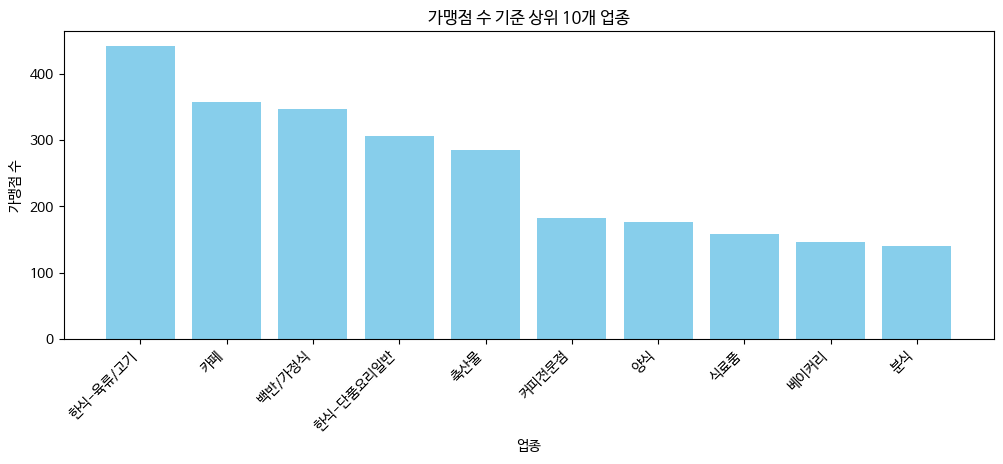

In [ ]:
# 상위 10개 업종 분포(막대그래프)
industry_freq = store_info['업종'].value_counts().head(10).reset_index()

plt.figure(figsize=(12, 4))
plt.bar(industry_freq['업종'], industry_freq['count'], color='skyblue')
plt.title('가맹점 수 기준 상위 10개 업종')
plt.xlabel('업종')
plt.ylabel('가맹점 수')
plt.xticks(rotation=45, ha='right')
plt.show()

- 주요업종
  - 한식-육류/고기, 카페, 백반/가정식, 한식-단품요리일반, 축산물, 커피전문점, 양식, 식료품, 베이커리, 분식

/tmp/ipython-input-1462870499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df_top10, x="가맹점수", y="상권명", ax=ax, palette="viridis")


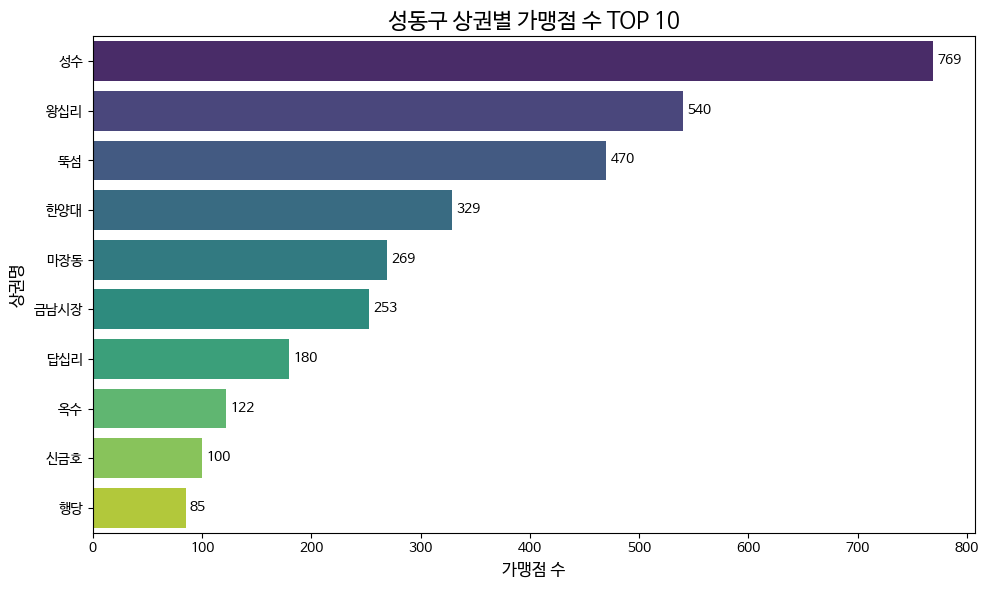

In [ ]:
# 상위 10개 상권 분포(막대그래프)

top10 = store_info["상권"].value_counts().head(10)
df_top10 = top10.reset_index()
df_top10.columns = ["상권명", "가맹점수"]

# 수평 막대 그래프
fig, ax = plt.subplots(figsize=(10,6))
bars = sns.barplot(data=df_top10, x="가맹점수", y="상권명", ax=ax, palette="viridis")

# 제목/라벨
ax.set_title("성동구 상권별 가맹점 수 TOP 10",  fontsize=16)
ax.set_xlabel("가맹점 수", fontsize=12)
ax.set_ylabel("상권명",  fontsize=12)

# ✅ 막대 끝에 수치(label) 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", padding=3, fontsize=10)

plt.tight_layout()
plt.show()

- 상위 상권 분포
  - 가맹점 수 기준 성수 - 왕십리 - 뚝섬 - 한양대 -마장동 -금남시장 - 답십리 - 옥수 - 신금호 - 행당 순으로 점포수가 많다.

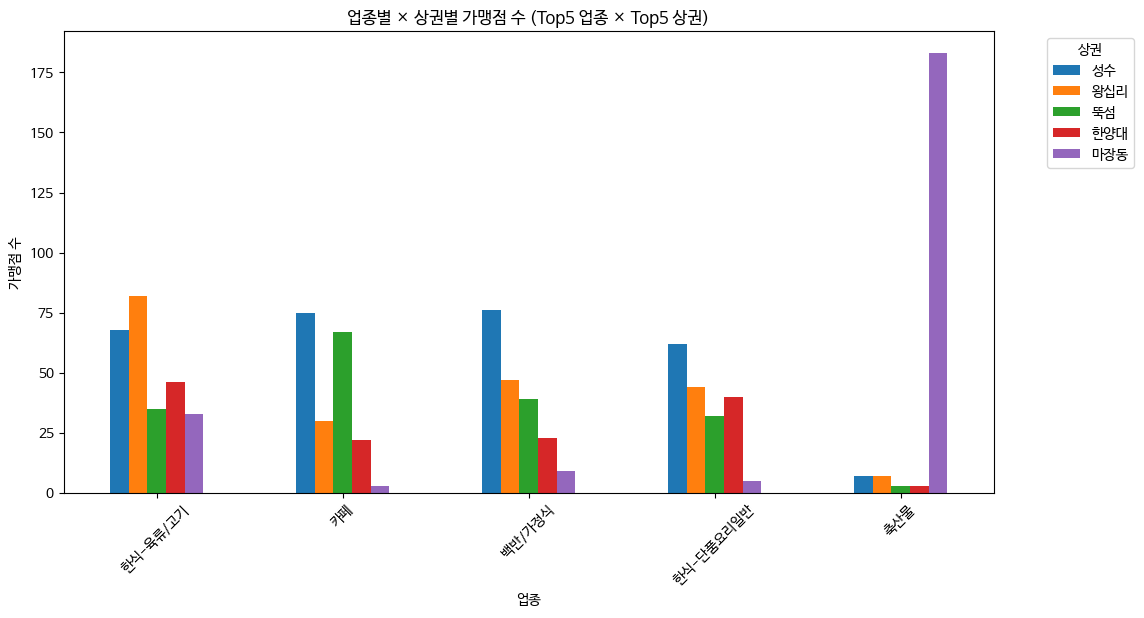

In [ ]:
# 업종별 상권 분포

# 지역 × 업종 교차표
cross_tab = pd.crosstab(store_info["업종"], store_info["상권"])

# 상위 5개 업종, 상위 5개 지역만 추리기
top5_industry = store_info["업종"].value_counts().head(5).index
top5_region = store_info["상권"].value_counts().head(5).index

cross_tab_sub = cross_tab.loc[top5_industry, top5_region]

# 업종X상권 Top5 분포
cross_tab_sub.plot(kind="bar", figsize=(12,6))
plt.title("업종별 × 상권별 가맹점 수 (Top5 업종 × Top5 상권)")
plt.xlabel("업종")
plt.ylabel("가맹점 수")
plt.xticks(rotation=45)
plt.legend(title="상권", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- 마장동의 경우 대부분의 업종에서 낮은 가맹점 수를 보이지만 축산물 업종에서 압도적으로 높은 가맹점 수를 기록하고 있다.

- 성수의 경우 한식-육류/고기, 카페, 백반/가정식 등 다양한 업종에서 고르게 분포되어 있어 균형잡힌 상권 구조임을 보여주고 있다.

- 왕십리의 경우 한식-육류/고기 업종에서 다른 업종보다 높은 가맹점 수를 기록하고 있다.

- 뚝섬의 경우 카페 업종에서 다른 업종보다 높은 가맹점 수를 기록하고 있다.


## 폐업일, 개설일 분포

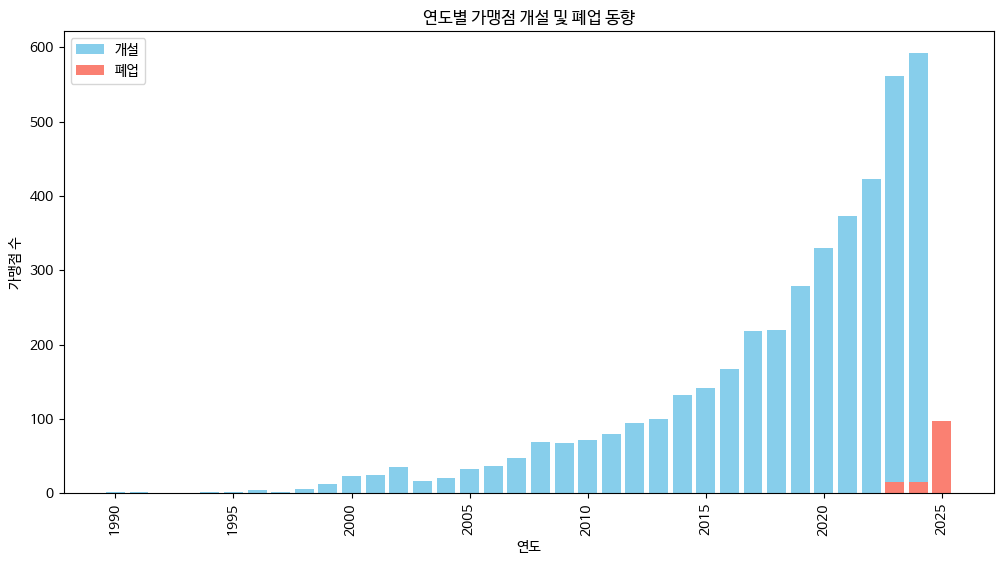

In [ ]:
# 연도별 개설일 & 폐업일 분포
store_info['개설연도'] = pd.to_datetime(store_info['개설일'], format='%Y%m%d', errors='coerce').dt.year
store_info['폐업연도'] = pd.to_datetime(store_info['폐업일'], format='%Y%m%d', errors='coerce').dt.year

# 연도별 개설 및 폐업 수 집계
openings_by_year = store_info['개설연도'].value_counts().sort_index()
closings_by_year = store_info['폐업연도'].value_counts().sort_index()

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.bar(openings_by_year.index, openings_by_year.values, color='skyblue', label='개설')
plt.bar(closings_by_year.index, closings_by_year.values, color='salmon', label='폐업')

plt.xlabel("연도")
plt.ylabel("가맹점 수")
plt.title("연도별 가맹점 개설 및 폐업 동향")
plt.xticks(rotation=90)
plt.legend()
plt.show()

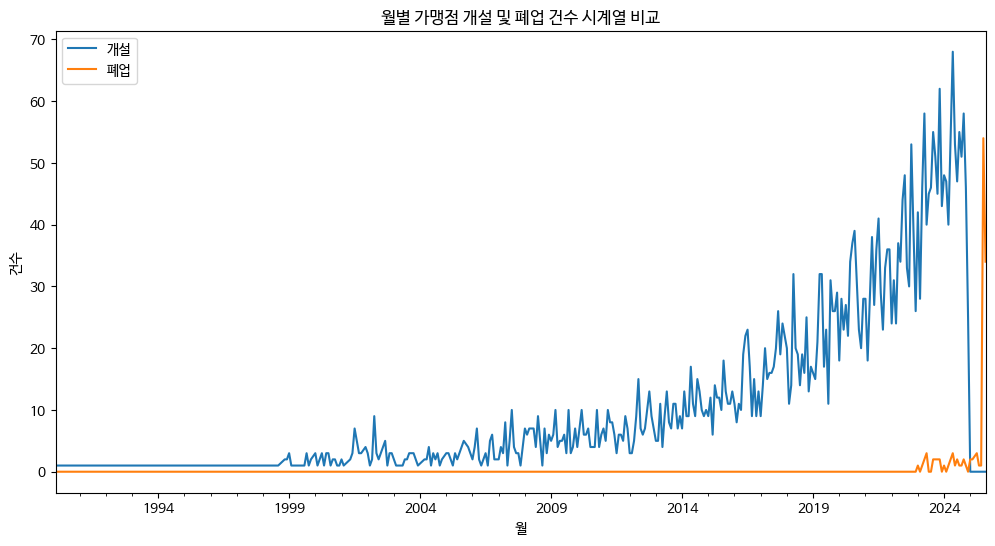

In [ ]:
# 월별 개설일 & 폐업일 분포
open = store_info['개설일'].dt.to_period('M').value_counts().sort_index()
close = store_info['폐업일'].dt.to_period('M').value_counts().sort_index()

df = pd.DataFrame({'개설': open, '폐업': close}).fillna(0)
df.plot(figsize=(12, 6))
plt.title('월별 가맹점 개설 및 폐업 건수 시계열 비교')
plt.xlabel('월')
plt.ylabel('건수')
plt.legend(['개설', '폐업'])
plt.show()

- 1990년부터 2024년까지 개설된 가게들의 정보이며 시간이 지남에 따라 개설 가맹점의 수가 점차 증가하는 추세를 보인다
- 폐업한 가맹점은 대부분 2025년도에 집중되어 있으며 일부는 2023년과 2024년에도 나타난다.


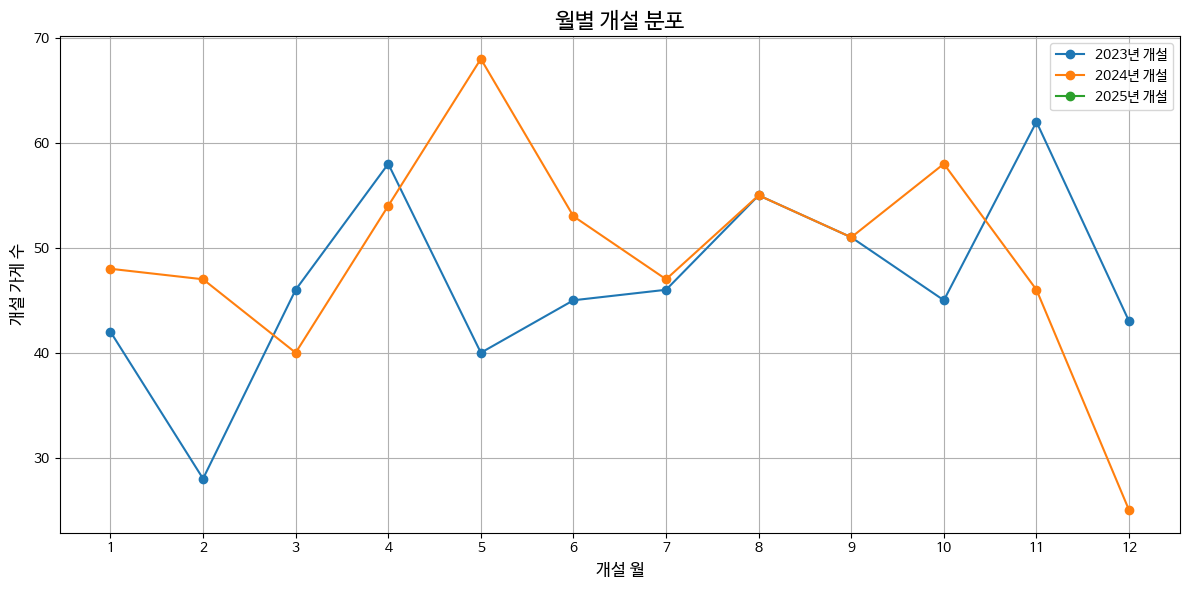

In [ ]:
# 월별 개설일 분포
opened_store = store_info[store_info["개설일"].notna()]
opened_store["개설연도"] = opened_store["개설일"].dt.year
opened_store["개설월"] = opened_store["개설일"].dt.month
target_years = [2023, 2024, 2025]

plt.figure(figsize=(12, 6))
for year in target_years:
  temp = opened_store[opened_store["개설연도"]==year]
  monthly_open_store = temp["개설월"].value_counts().sort_index()
  plt.plot(monthly_open_store.index, monthly_open_store.values, marker='o', label=f"{year}년 개설")


plt.title("월별 개설 분포", fontsize=16)
plt.xlabel("개설 월", fontsize=12)
plt.ylabel("개설 가게 수", fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- 2023년과 2024년 모두 특정 달에 개설 가게 수의 급격한 증감이 나타난다.
-	연초부터 봄 초반까지는 신규 가게 개설 수가 증가하는 경향이 있으며 특히 4월에는 두 해 모두 급증하는 것이 특징이다.
- 연말인 12월에는 두 해 모두 개설 수가 크게 감소하는 공통점이 명확하다. 이는 연말에는 신규 창업이 줄어드는 시기임을 시사한다.

-	즉, 2023년과 2024년은 계절별로 신규 개설 가게가 증가하는 시기와 감소하는 시기가 비슷한 흐름을 보이고 있다.

/tmp/ipython-input-3380587525.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closed_store["폐업연도"] = closed_store["폐업일"].dt.year
/tmp/ipython-input-3380587525.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closed_store["폐업월"] = closed_store["폐업일"].dt.month


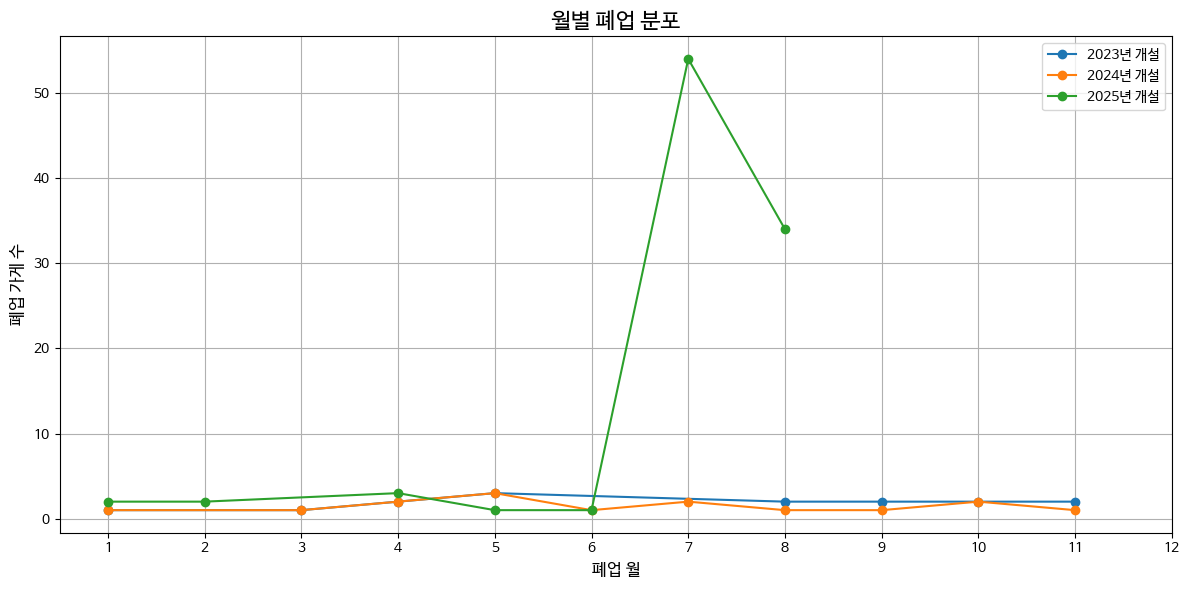

In [ ]:
# 월별 폐업 분포
closed_store = store_info[store_info["폐업일"].notna()]
closed_store["폐업연도"] = closed_store["폐업일"].dt.year
closed_store["폐업월"] = closed_store["폐업일"].dt.month
target_years = [2023, 2024, 2025]

plt.figure(figsize=(12, 6))
for year in target_years:
  temp = closed_store[closed_store["폐업연도"]==year]
  monthly_closed_store = temp["폐업월"].value_counts().sort_index()
  plt.plot(monthly_closed_store.index, monthly_closed_store.values, marker='o', label=f"{year}년 개설")


plt.title("월별 폐업 분포", fontsize=16)
plt.xlabel("폐업 월", fontsize=12)
plt.ylabel("폐업 가게 수", fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- 2025년 7, 8월에 압도적으로 페업수가 증가했으며, 폐업한 가맹점 대부분의 기록이 2025년 7월 이후에 집중되어 있음을 의미한다.

-	그 외의 기간에는 모든 연도와 월의 폐업 가게 수가 비교적 비슷한 수준을 유지하고 있다.

## 업종 및 상권별 폐업률

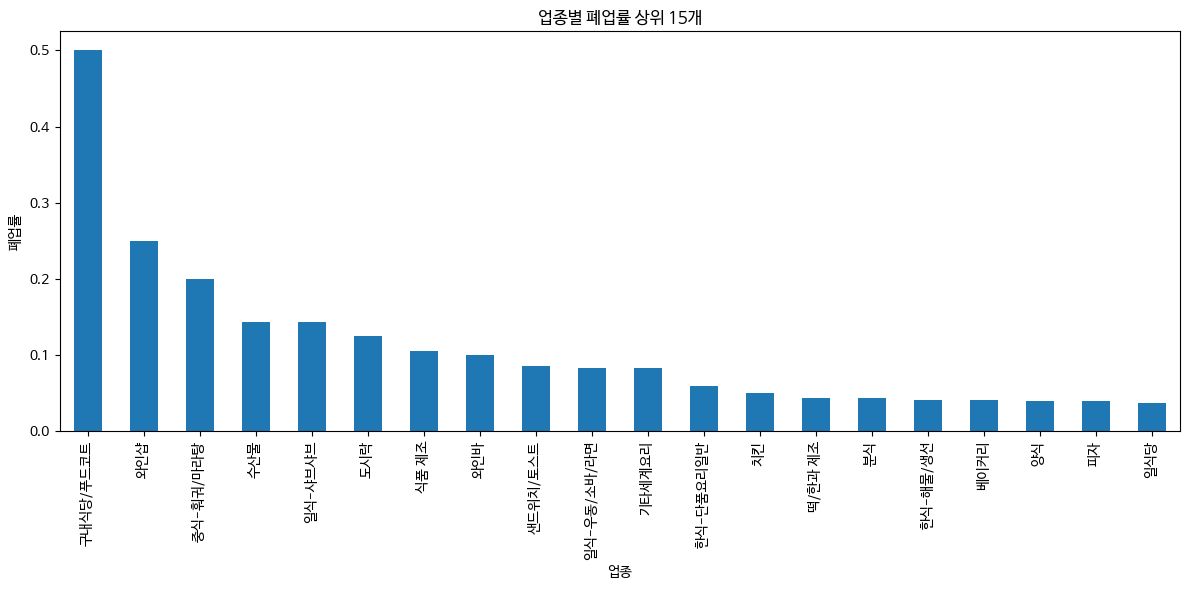

In [ ]:
# 업종별 폐업률
# 폐업여부 컬럼 생성 (폐업일이 결측이면 0(영업중), 있으면 1(폐업))
store_info['폐업여부'] = store_info['폐업일'].isna().apply(lambda x: 0 if x else 1)

# 업종별 영업/폐업 가맹점 수 집계
industry_closure = store_info.groupby(['업종', '폐업여부']).size().unstack(fill_value=0)
industry_closure['폐업률'] = industry_closure[1] / (industry_closure[0] + industry_closure[1])

# 폐업률 기준 상위 N개 업종 그래프
top = industry_closure.sort_values('폐업률', ascending=False).head(20)
top[['폐업률']].plot(kind='bar', figsize=(12,6), legend=False)
plt.title('업종별 폐업률 상위 15개')
plt.ylabel('폐업률')
plt.xlabel('업종')
plt.tight_layout()
plt.show()


-	구내식당/푸드코드 업종이 압도적으로 높은 폐업률을 기록하고 있다.

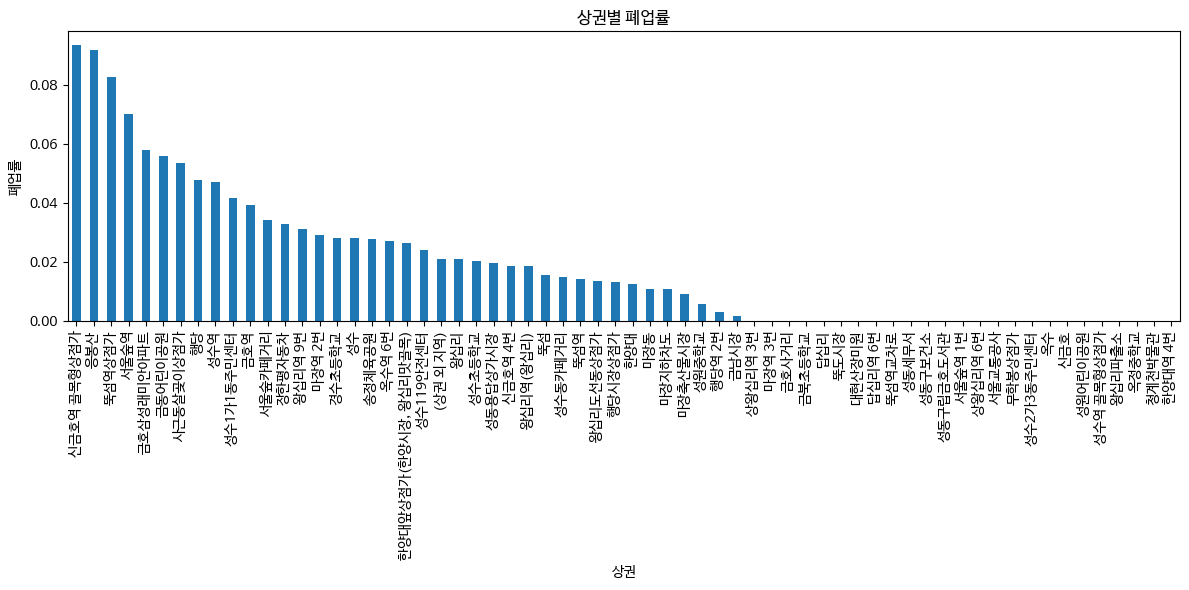

In [ ]:
## 상권 결측치 처리 완료된 all_data_v1.csv 로 상권별 폐업률 확인


path0 = "/content/drive/MyDrive/[LG 8기] HHGG 공모전/0_data/all_data_v1_update.csv"
all_data_v1_update = pd.read_csv(path0, encoding='utf8')

# 상권별 폐업률

# 상권별 영업/폐업 가맹점 수 집계
area_closure = all_data_v1_update.groupby(['상권', '폐업여부']).size().unstack(fill_value=0)
area_closure['폐업률'] = area_closure[True] / (area_closure[True] + area_closure[False])



# 폐업률 기준 상권 그래프
top = area_closure.sort_values('폐업률', ascending=False)
top[['폐업률']].plot(kind='bar', figsize=(12,6), legend=False)
plt.title('상권별 폐업률')
plt.ylabel('폐업률')
plt.xlabel('상권')
plt.tight_layout()
plt.show()

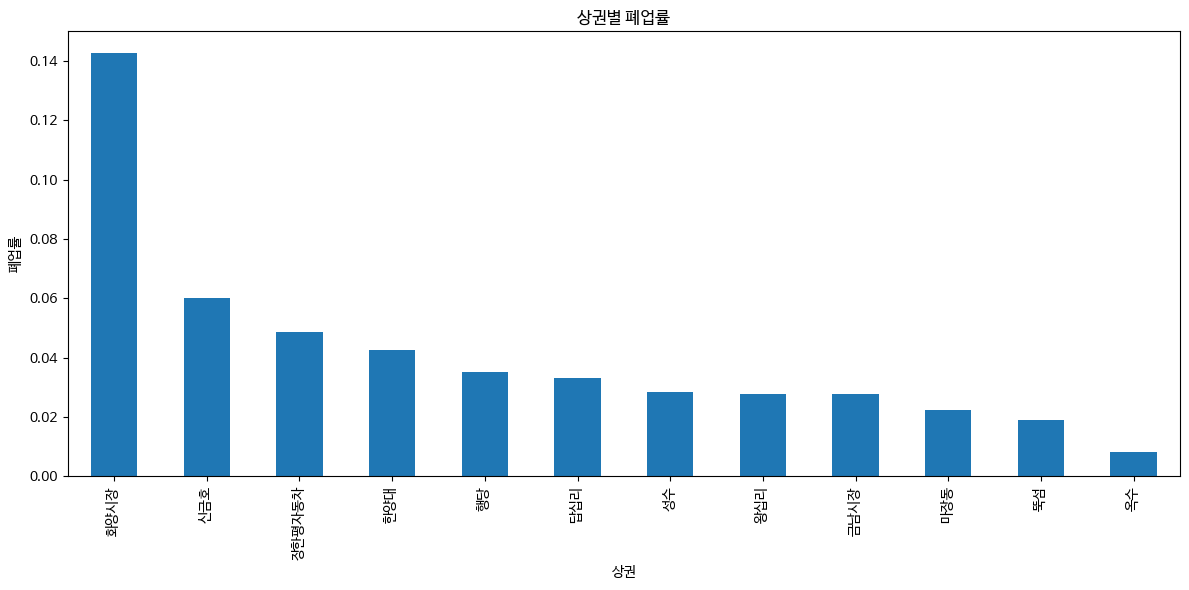

In [ ]:
# 상권별 폐업률

# 상권별 영업/폐업 가맹점 수 집계
area_closure = store_info.groupby(['상권', '폐업여부']).size().unstack(fill_value=0)
area_closure['폐업률'] = area_closure[1] / (area_closure[0] + area_closure[1])

# 폐업률 기준 상권 그래프
top = area_closure.sort_values('폐업률', ascending=False).head(15)
top[['폐업률']].plot(kind='bar', figsize=(12,6), legend=False)
plt.title('상권별 폐업률')
plt.ylabel('폐업률')
plt.xlabel('상권')
plt.tight_layout()
plt.show()

-	폐업률이 가장 높은 상권은 신금호, 장한평자동차, 한양대 등으로 나타났다.

-	동대문역사문화공원역, 건대입구, 오남 등 폐업률이 0에 가까운 상권은 성동구가 아닌 위치이므로 잘못 표기된 상권인지 확인이 필요하다.

In [ ]:
# # 연도-월별 상권별 폐업 점포 수 집계
# closed_store['폐업년월'] = closed_store['폐업일'].dt.to_period('M').astype(str)
# monthly_closed = closed_store.groupby(['상권', '폐업년월']).size().reset_index(name='폐업건수')

# # 연도-월별 상권별 전체 점포 수 집계
# store_info['개설년월'] = store_info['개설일'].dt.to_period('M').astype(str)
# monthly_total = store_info.groupby(['상권', '개설년월']).size().reset_index(name='전체점포수')
# # 폐업년월과 개설년월 컬럼명이 달라서 병합 기준 맞춤
# monthly_total.rename(columns={'개설년월': '폐업년월'}, inplace=True)

# # 병합 후 폐업률 계산
# merged = pd.merge(monthly_closed, monthly_total, on=['상권', '폐업년월'], how='left')
# merged['폐업률'] = merged['폐업건수'] / merged['전체점포수'] * 100

# print(merged)

# # # 6. 폐업률 계산 위해 monthly_closed와 total_stores 병합
# # merged = pd.merge(monthly_closed, total_stores, on='상권', how='left')

# # # 7. 폐업률(%) 계산
# # merged['폐업률'] = merged['폐업건수'] / merged['총점포수'] * 100

# # # 8. 결과 확인
# # print(merged)

# # # 추가적으로 시각화 시 matplotlib 또는 seaborn 사용 가능


## 폐업 가맹점의 유지기간

/tmp/ipython-input-321936437.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closed["유지기간_일"] = (closed["폐업일"] - closed["개설일"]).dt.days
/tmp/ipython-input-321936437.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closed["유지기간_월"] = (closed["유지기간_일"] / 30.44).round(1)
/tmp/ipython-input-321936437.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

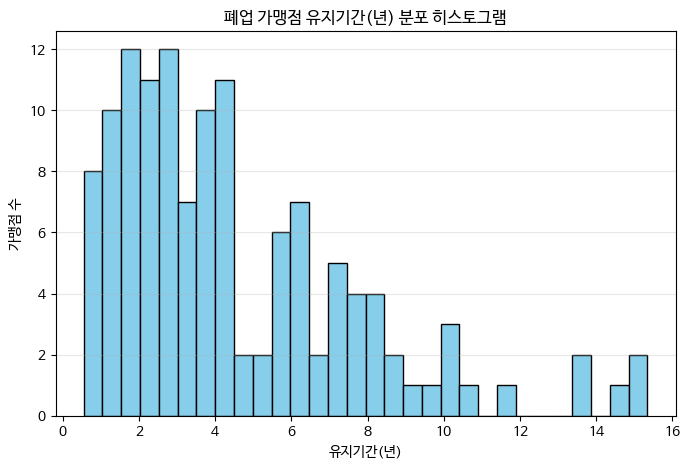

In [ ]:
# 폐업 가맹점의 유지기간 확인

# 1) 날짜형 변환 (YYYYMMDD → datetime)
store_info["개설일"] = pd.to_datetime(store_info["개설일"], format="%Y%m%d", errors="coerce")   # 개설일
store_info["폐업일"] = pd.to_datetime(store_info["폐업일"], format="%Y%m%d", errors="coerce") # 폐업일

# 2) 폐업한 가맹점 추출
closed = store_info[store_info["폐업일"].notna()]
# 3) 유지기간 계산
closed["유지기간_일"] = (closed["폐업일"] - closed["개설일"]).dt.days
closed["유지기간_월"] = (closed["유지기간_일"] / 30.44).round(1)
closed["유지기간_년"] = (closed["유지기간_일"] / 365).round(2)

# 유지기간_월 기준 히스토그램
plt.figure(figsize=(8, 5))
plt.hist(closed["유지기간_년"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("유지기간(년)")
plt.ylabel("가맹점 수")
plt.title("폐업 가맹점 유지기간(년) 분포 히스토그램")
plt.grid(axis='y', alpha=0.3)
plt.show()

- 개설일로부터 1 ~ 4년 사이에 폐업한 가맹점 수가 많아 단기간(2 ~ 3년차)에 폐업 위험이 집중됨을 알 수 있다.
- 6년이상 운영한 가맹점의 폐업은 점차 줄어들며 장기 운영된 가맹점일수록 폐업의 확률이 낮아짐을 의미한다.

# Dataset 2 : 가맹점 월별 이용 정보
  데이터 이름: store_sales

In [ ]:
# 데이터 확인
store_sales.head()

,가맹점구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [ ]:
# 데이터 요약 정보
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   가맹점구분번호            86590 non-null  object 
 1   기준년월               86590 non-null  int64  
 2   가맹점 운영개월수 구간       86590 non-null  object 
 3   매출금액 구간            86590 non-null  object 
 4   매출건수 구간            86590 non-null  object 
 5   유니크 고객 수 구간        86590 non-null  object 
 6   객단가 구간             86590 non-null  object 
 7   취소율 구간             79958 non-null  object 
 8   배달매출금액 비율          86590 non-null  float64
 9   동일 업종 매출금액 비율      86590 non-null  float64
 10  동일 업종 매출건수 비율      86590 non-null  float64
 11  동일 업종 내 매출 순위 비율   86590 non-null  float64
 12  동일 상권 내 매출 순위 비율   86590 non-null  float64
 13  동일 업종 내 해지 가맹점 비중  86590 non-null  float64
 14  동일 상권 내 해지 가맹점 비중  86590 non-null  float64
dtypes: float64(7), int64(1), object(7)
memory usage: 9.9+ MB


##(전처리) -999999.9를 NaN으로

In [ ]:
# 결측값 확인
store_sales.replace(-999999.9, np.nan, inplace=True)
store_sales.isnull().sum()

,0
가맹점구분번호,0
기준년월,0
가맹점 운영개월수 구간,0
매출금액 구간,0
매출건수 구간,0
유니크 고객 수 구간,0
객단가 구간,0
취소율 구간,6632
배달매출금액 비율,57345
동일 업종 매출금액 비율,0


## (전처리) 구간 컬럼 수치형으로 변환

In [ ]:
# 구간컬럼 수치형으로 변환
panel = ['가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간']

#취소율에 null 값 있어서 if isinstance(x, str) 사용해서 문자열인지 확인 후 문자열이 아니면 nan 유지
for col in panel:
  store_sales[col] = store_sales[col].apply(
      lambda x: x.split('_')[0] if isinstance(x, str) else np.nan
  )

store_sales[panel] = store_sales[panel].applymap(
    lambda x: int(x) if pd.notnull(x) and str(x).isdigit() else x
)

# datetime으로 바꾸기
store_sales["기준년월"] = pd.to_datetime(store_sales["기준년월"], format = "%Y%m")

store_sales.head()

/tmp/ipython-input-3557168753.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  store_sales[panel] = store_sales[panel].applymap(


,가맹점구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중
0,000F03E44A,2024-04-01,4,5,5,5,5,1.0,NaN,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,2023-12-01,4,6,6,6,6,NaN,NaN,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,2024-04-01,2,3,4,4,2,6.0,NaN,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,2024-11-01,2,3,4,4,2,6.0,NaN,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,2024-06-01,2,4,4,4,2,1.0,NaN,74.2,38.1,16.0,19.9,17.3,5.6


## 월별 매출 추세

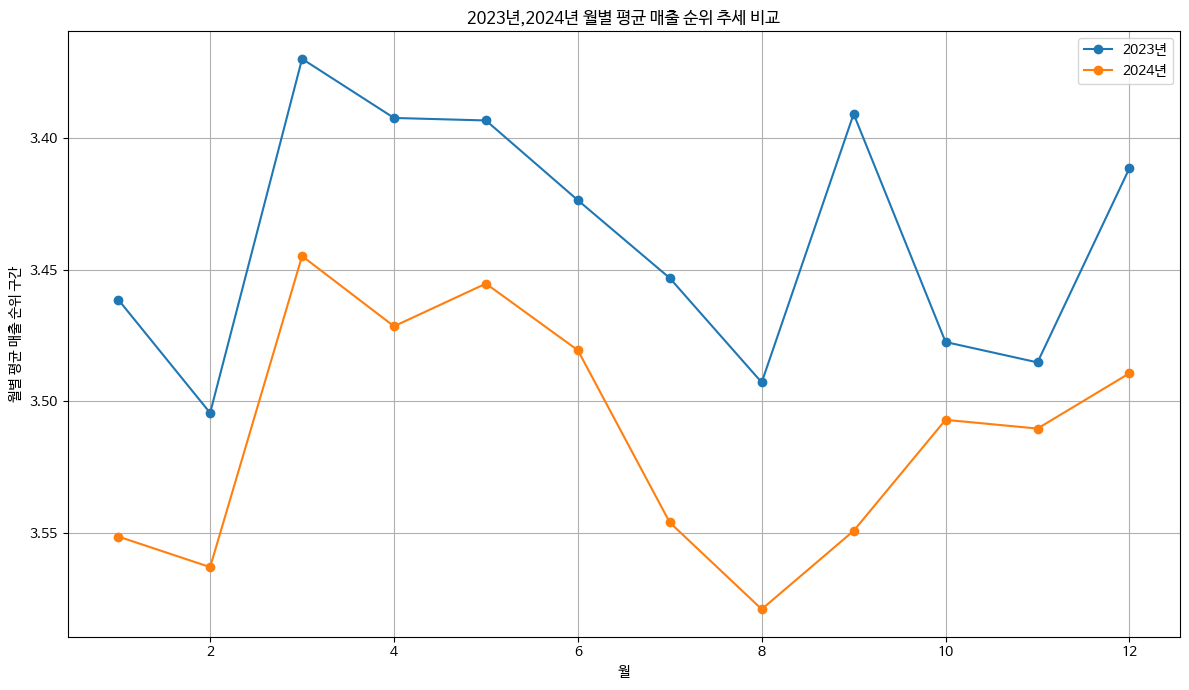

In [ ]:
# 월별 매출금액 구간 평균
monthly_sales_rank_avg = store_sales.groupby('기준년월')['매출금액 구간'].mean()

# 연도와 월 추출
store_sales['연도'] = store_sales['기준년월'].dt.year.astype(str)
store_sales['월'] = store_sales['기준년월'].dt.month

# 연도, 월별 평균 구하기
monthly_avg = store_sales.groupby(['연도', '월'])['매출금액 구간'].mean().unstack(0)

plt.figure(figsize=(12, 7))

# 2023년, 2024년 데이터 선그래프
plt.plot(monthly_avg.index, monthly_avg['2023'], marker='o', label='2023년')
plt.plot(monthly_avg.index, monthly_avg['2024'], marker='o', label='2024년')

plt.title('2023년,2024년 월별 평균 매출 순위 추세 비교')
plt.xlabel('월')
plt.ylabel('월별 평균 매출 순위 구간')

plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


-	2023년, 2024년에 확실히 유사한 패턴이 나타났다.

-	2월, 8월에 저점을 기록하고 3월, 12월에 고점을 기록했다.

-	이러한 2월(저점), 3월(고점), 8월(저점), 12월(고점)의 매출 기록은 계절적으로 반복되는 주기를 가짐을 의미한다.


## 전체 변수간의 상관관계 분석

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


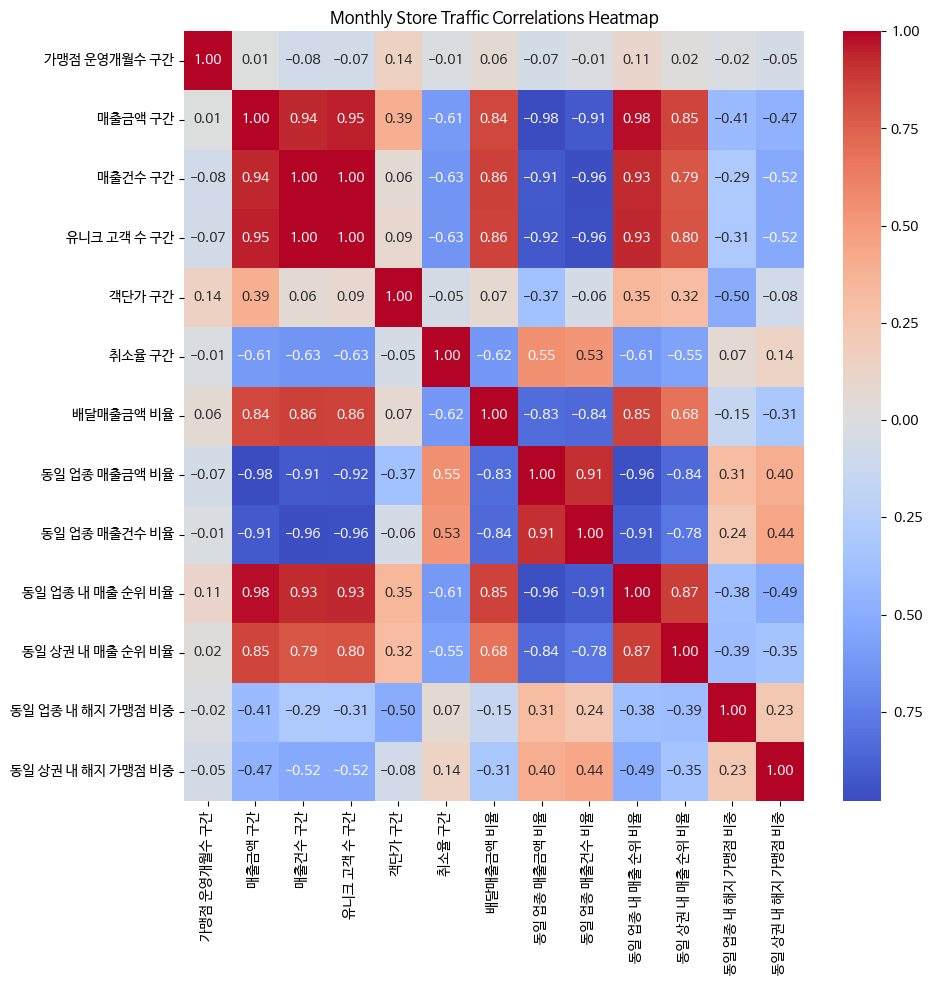

In [ ]:
# 전체 변수간의 상관관계 분석

# 원하는 열만 선택
selected_columns_ss = ['가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간',
                       '배달매출금액 비율',	'동일 업종 매출금액 비율',	'동일 업종 매출건수 비율',	'동일 업종 내 매출 순위 비율',	'동일 상권 내 매출 순위 비율',
                       	'동일 업종 내 해지 가맹점 비중',	'동일 상권 내 해지 가맹점 비중']
store_sales_selected = store_sales[selected_columns_ss]

# 상관관계 계산
correlation_matrix_ss = store_sales_selected.corr()

# 히트맵 시각화
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix_ss.corr(), annot=True, cmap = 'coolwarm', fmt=".2f")
plt.title("Monthly Store Traffic Correlations Heatmap")
plt.show()

- 매출금액 & 유니크 고객 수, 배달 매출금액 (0.9-0.8대)
- 유니크 고객 수 & 매출금액, 배달매출금액, 동일업종/상권 내 매출 순위(0.9-0.8), 동일업종/상권 내 금액 비율(-0.9대)
- 배달매출금액 비율, 동일업종 내 매출 순위 비율
- 동일 업종 매출금액 높으면 건수 높음
- 동일 업종 내 매출 순위 높음면 동일 상권도 높음

- 동일 업종 내 매출 순위 비율이랑 동일 업종 매출 금액 비율 반비례
- 동일 업종 내 매출 순위 비율이랑 동일 업종 매출 건수 비율 반비례

# Dataset 1 + Dataset 2

In [ ]:
# data1, data2 join
merged_1and2 = pd.merge(store_info, store_sales, on="가맹점구분번호", how="outer")

##(전처리) 25.7월 이전에 폐업한 가맹점 제외

In [ ]:
#  2025년 7월 이전에 폐업한 가맹점 추출
cutoff = pd.Timestamp("2025-07-01")
closed_before_cutoff = merged_1and2[
    (merged_1and2['폐업여부'] == True) &
    (merged_1and2['폐업일'] < cutoff)
]

In [ ]:
# 추출한 가맹점의 고유번호 확인
drop_store_num = closed_before_cutoff['가맹점구분번호'].unique()

# 해당 가맹점을 전체 데이터에서 제외
merged_1and2 = merged_1and2[~merged_1and2['가맹점구분번호'].isin(drop_store_num)]

## 상권별 평균 매출 추세

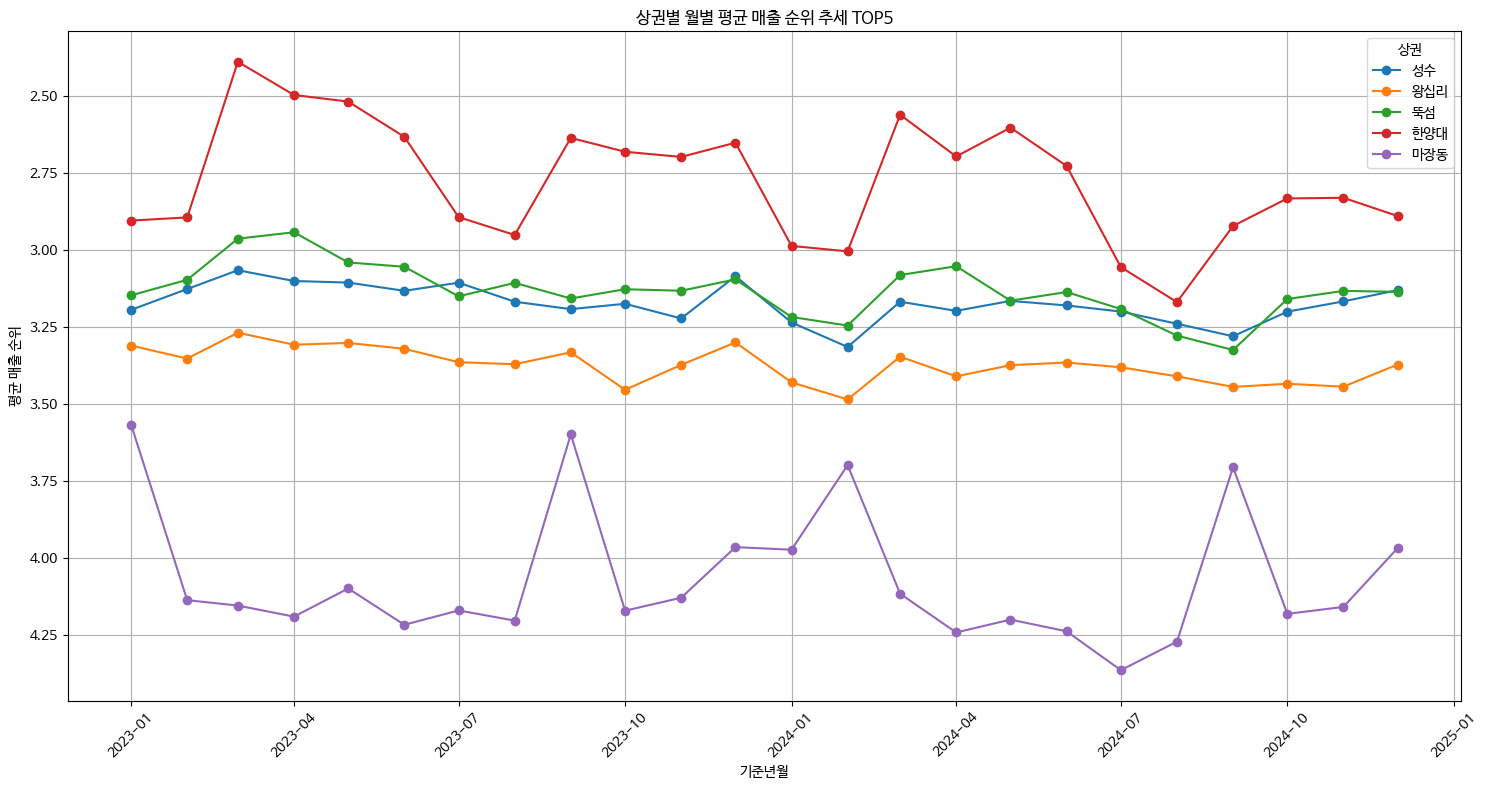

In [ ]:
# 상권별 월별 평균 매출 순위 집계
monthly_sales_by_commercial_area = merged_1and2.groupby(['상권', '기준년월'])['매출금액 구간'].mean().reset_index()
# 가맹점 수 상위 5개
top_5_commercial_areas = ['성수','왕십리','뚝섬','한양대','마장동']
# 상위 5개 상권 데이터 필터링
filtered_monthly_sales = monthly_sales_by_commercial_area[monthly_sales_by_commercial_area['상권'].isin(top_5_commercial_areas)]
# 시각화
plt.figure(figsize=(15, 8))

for area in top_5_commercial_areas:
    area_data = filtered_monthly_sales[filtered_monthly_sales['상권'] == area]
    plt.plot(area_data['기준년월'], area_data['매출금액 구간'], marker='o', linestyle='-', label=area)

plt.title('상권별 월별 평균 매출 순위 추세 TOP5')
plt.xlabel('기준년월')
plt.ylabel('평균 매출 순위')
plt.xticks(rotation=45)
plt.legend(title='상권')
plt.grid(True)
plt.gca().invert_yaxis() # y축 반전 (낮은 순위가 위에 오도록)
plt.tight_layout()
plt.show()

-	2023년부터 2024년까지 상권별로 평균 매출 순위를 나타낸 정보이며 가장 높은 평균 매출을 기록한 상권은 한양대이다.

-	마장동의 매출 추세는 TOP5 상권 중에서 가장 낮은 순위를 보이며 한양대의 매출 추세와 정반대의 흐름을 나타낸다.

-	왕십리, 뚝섬, 성수의 매출 추세는 비슷한 패턴을 보인다.


## 폐업 가맹점 vs 운영 가맹점

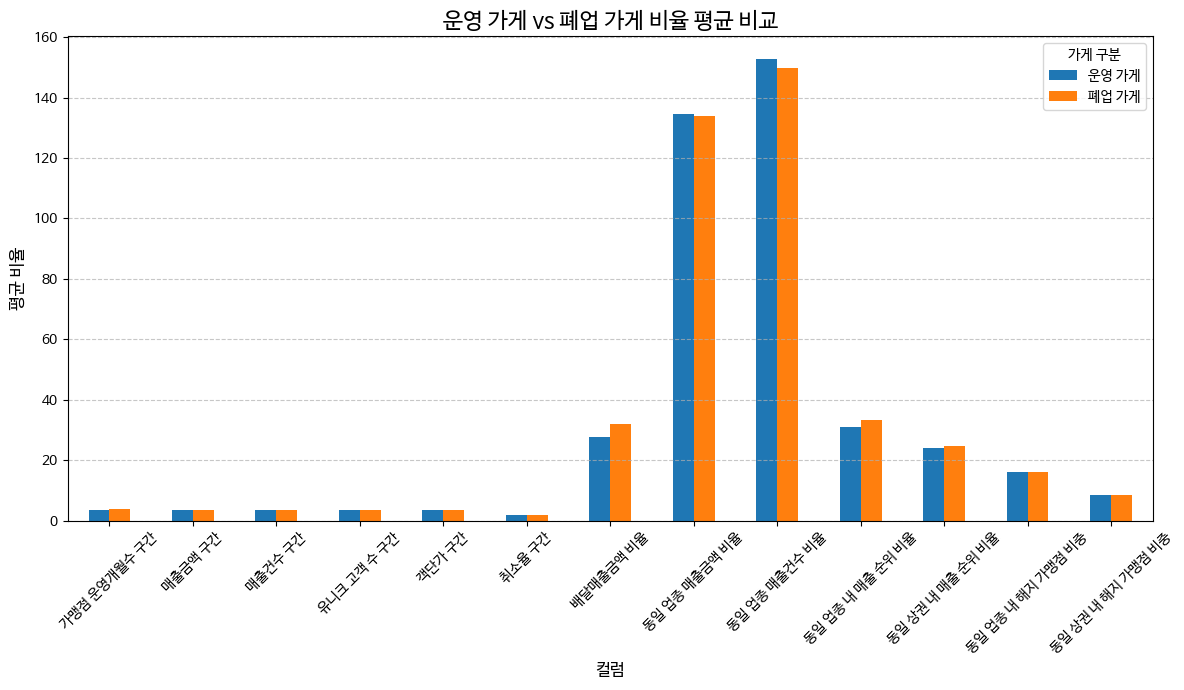

In [ ]:
# 폐업한 가게 vs 전체 가게
# 모든 컬럼 평균 비교
merged_closed_store = merged_1and2[merged_1and2["폐업일"].notna()]
merged_open_store = merged_1and2[merged_1and2["폐업일"].isna()]
ratio_columns = ['가맹점 운영개월수 구간',	'매출금액 구간',	'매출건수 구간',	'유니크 고객 수 구간',	'객단가 구간',	'취소율 구간',	'배달매출금액 비율',	'동일 업종 매출금액 비율','동일 업종 매출건수 비율',	'동일 업종 내 매출 순위 비율',	'동일 상권 내 매출 순위 비율',
                 '동일 업종 내 해지 가맹점 비중',	'동일 상권 내 해지 가맹점 비중']
merged_closed_mean = merged_closed_store[ratio_columns].mean()
merged_open_mean = merged_open_store[ratio_columns].mean()
#merged_all_mean = merged_1and2[ratio_columns].mean()

# 데이터프레임으로 결합
merged_compare = pd.DataFrame({
    '운영 가게': merged_open_mean,
    '폐업 가게': merged_closed_mean
})

# 막대 그래프 그리기
merged_compare.plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('운영 가게 vs 폐업 가게 비율 평균 비교', fontsize=16)
plt.ylabel('평균 비율', fontsize=12)
plt.xlabel('컬럼', fontsize=12)
plt.legend(title='가게 구분')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

-	폐업한 가게와 폐업하지 않은 가게의 컬럼들의 평균을 비교했다.

-	배달매출금액 비율, 동일 업종 매출금액 비율, 동일 업종 매출건수 비율 등 매출에 관련한 컬럼들에서 차이가 있음을 알 수 있다.

### 가맹점 운영개월수 비교

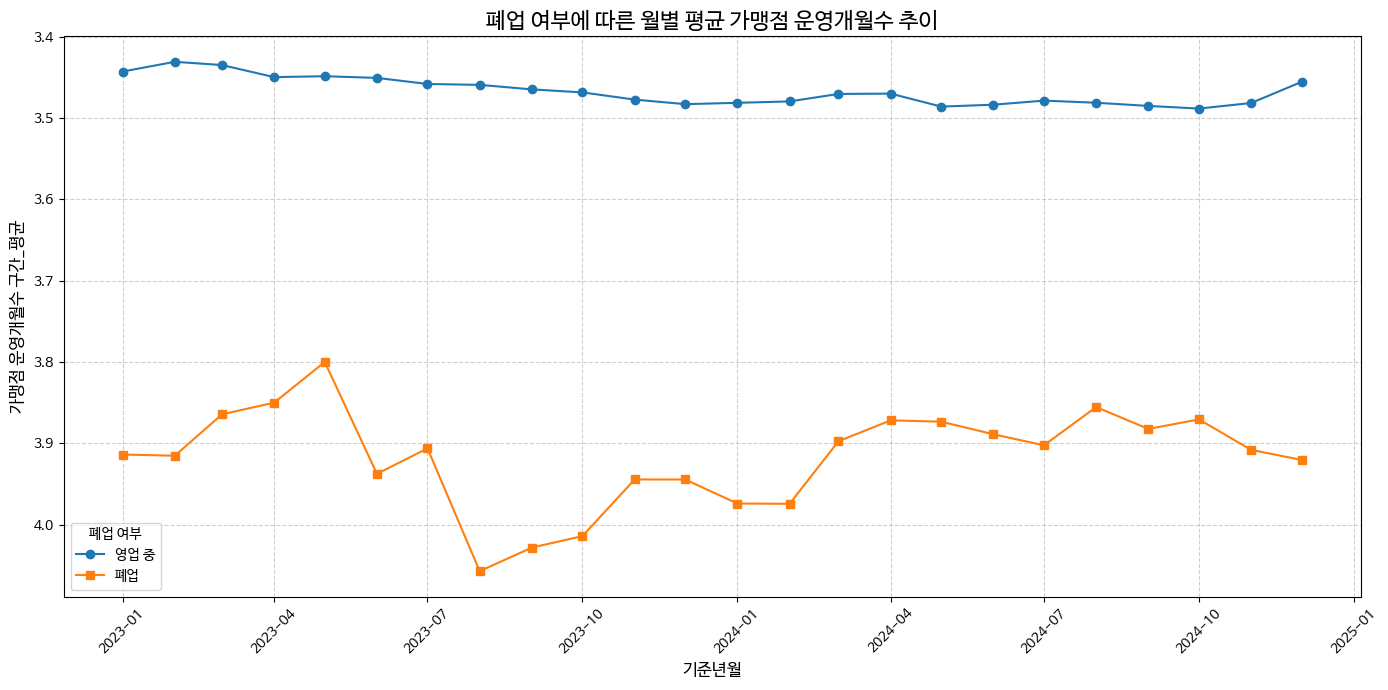

In [ ]:
# 폐업유무에 따른 매출 추세 비교
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='가맹점 운영개월수 구간',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 가맹점 운영개월수 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('가맹점 운영개월수 구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###매출금액 비교

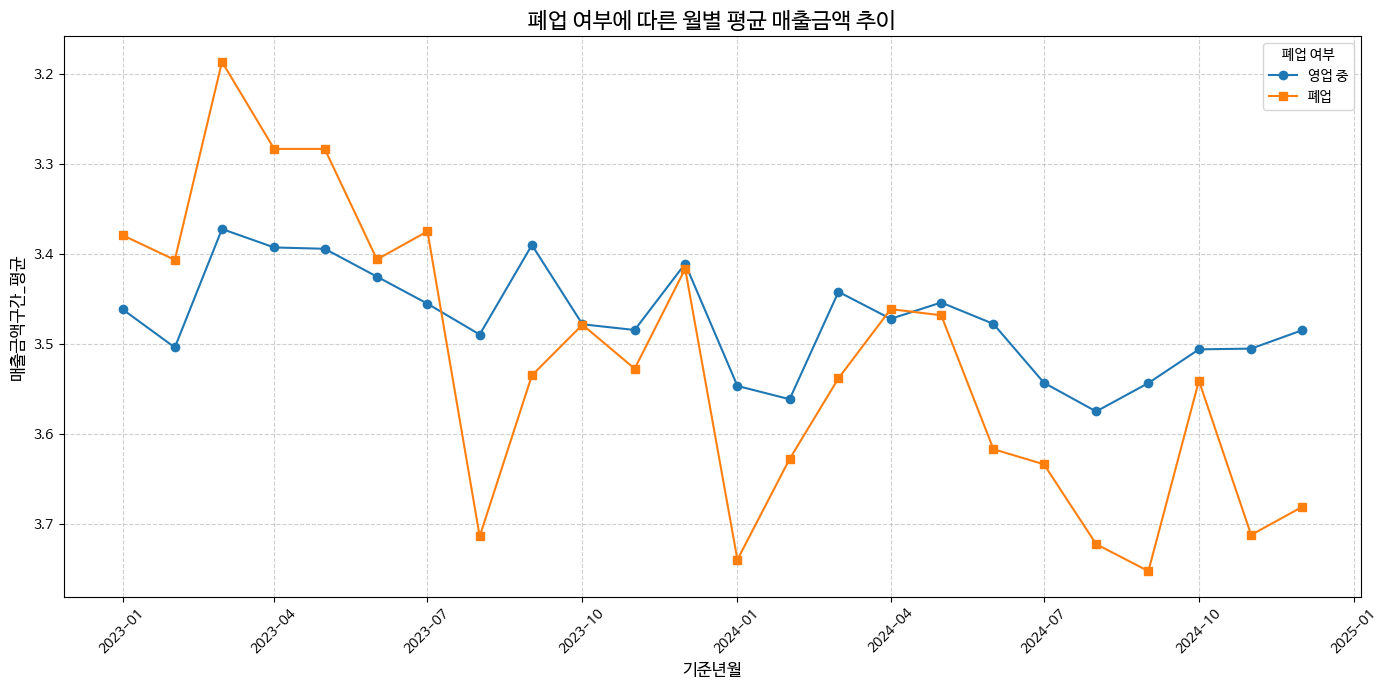

In [ ]:
# 폐업유무에 따른 매출 추세 비교
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='매출금액 구간',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 매출금액 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('매출금액구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

-	폐업 여부에 따른 평균 매출 금액 구간 추세를 봤을 때 상승, 하강의 흐름이 비슷하나 전반적으로 폐업한 가맹점의 매출이 더 낮은 추세를 보인다.
- 폐업한 가맹점의 매출 변동폭이 커 불안정한 패턴을 보이며 2024년 4~9월 지속적으로 하락하는 경향을 보인다.

### 유니크 고객 수 비교

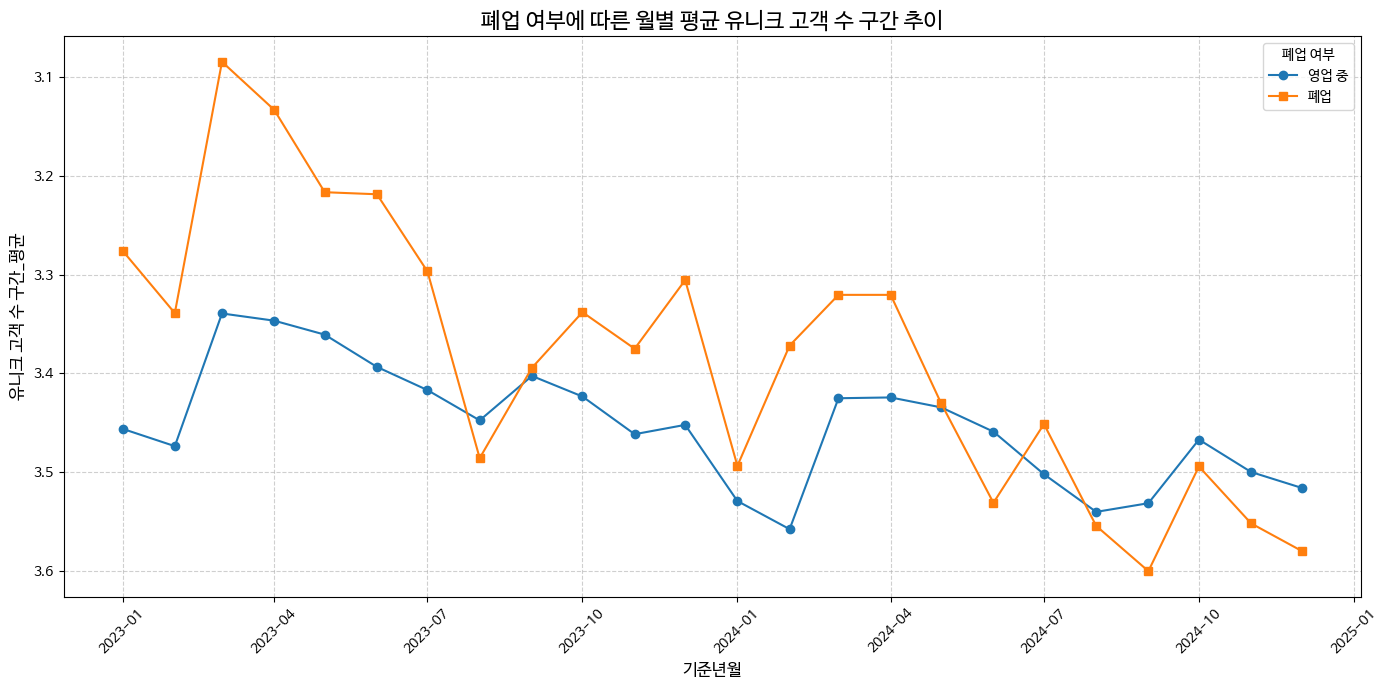

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='유니크 고객 수 구간',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 유니크 고객 수 구간 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('유니크 고객 수 구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 객단가  비교

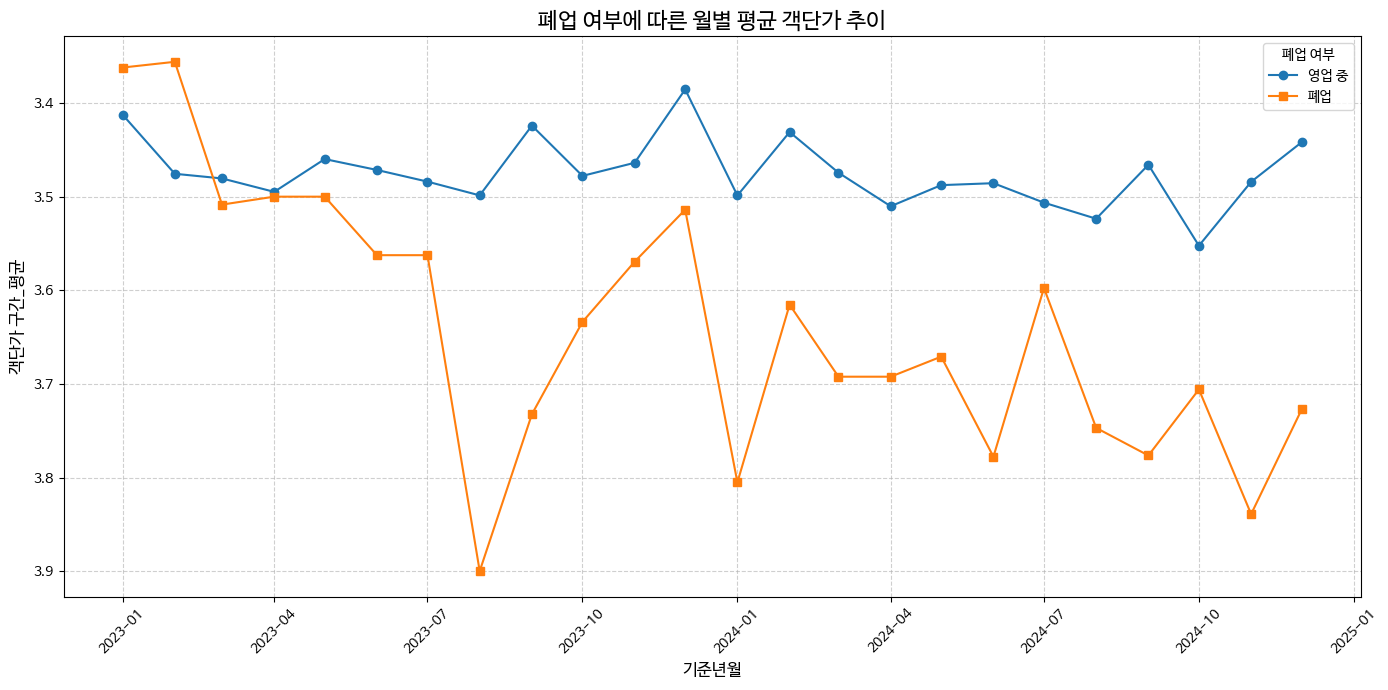

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='객단가 구간',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 객단가 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('객단가 구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 취소율 비교

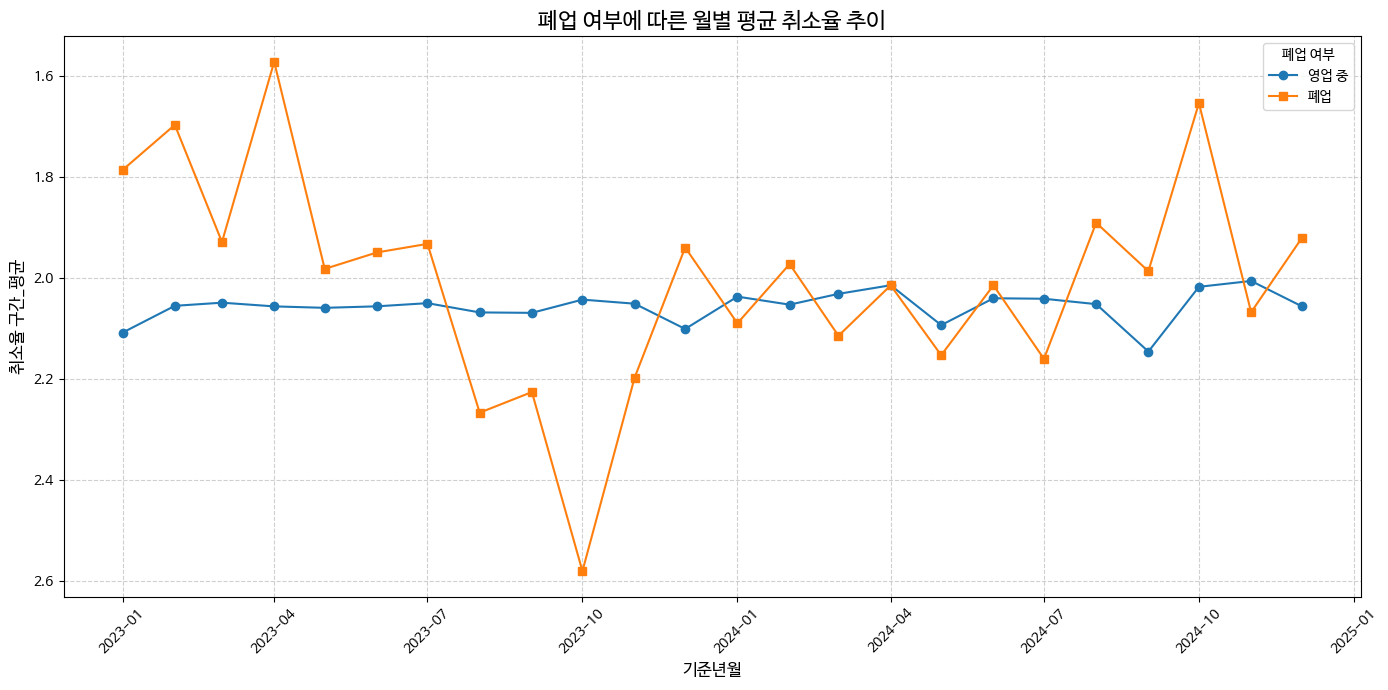

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='취소율 구간',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 취소율 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('취소율 구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 배달매출금액 비교

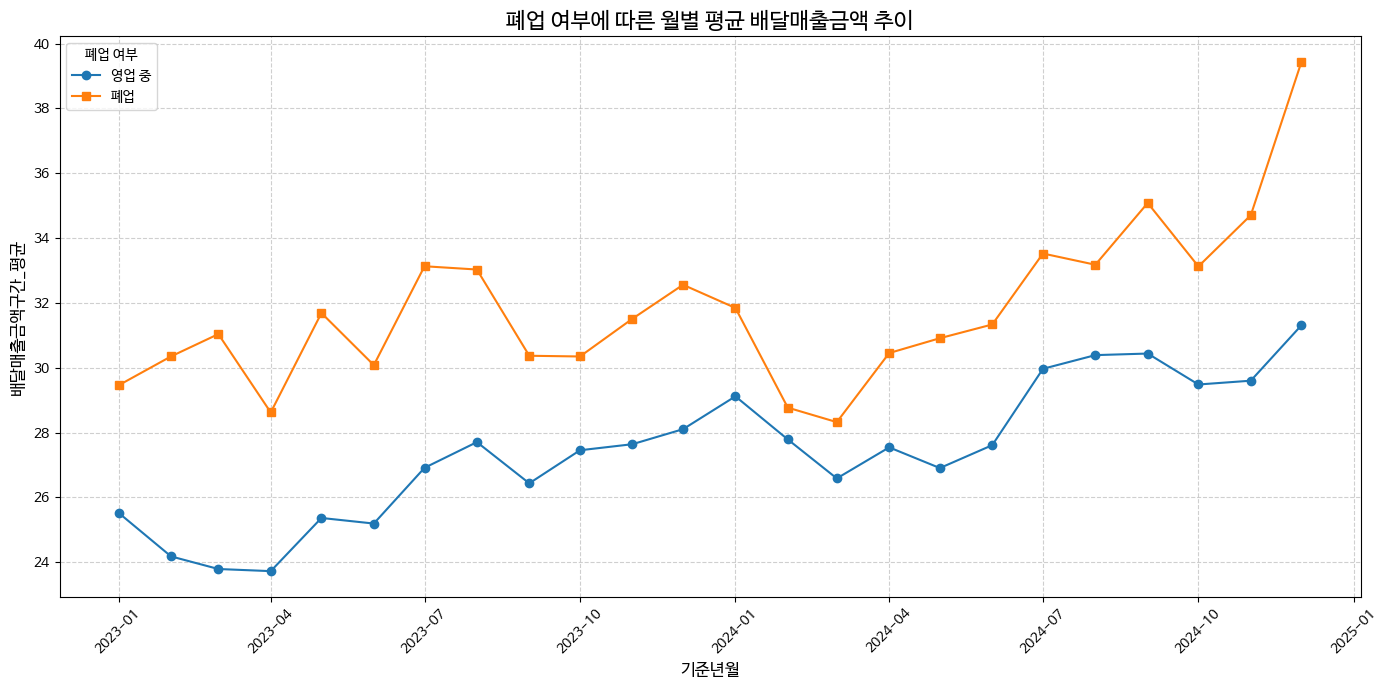

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='배달매출금액 비율',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.title('폐업 여부에 따른 월별 평균 배달매출금액 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('배달매출금액구간_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 폐업한 가맹점과 영업 중인 가맹점의 매출은 대체로 비슷한 추세를 보이고 있다. 그러나 폐업한 가맹점의 평균 배달 매출은 더 높게 나타난다.
- 앞선 분석에서 전체 매출평균은 폐업한 가맹점이 더 낮았던 점을 감안할 때, 폐업한 가맹점 중에는  배달전문 가맹점이 포함되어 있을 가능성이 있다.

###동일 업종 매출금액 비율 비교

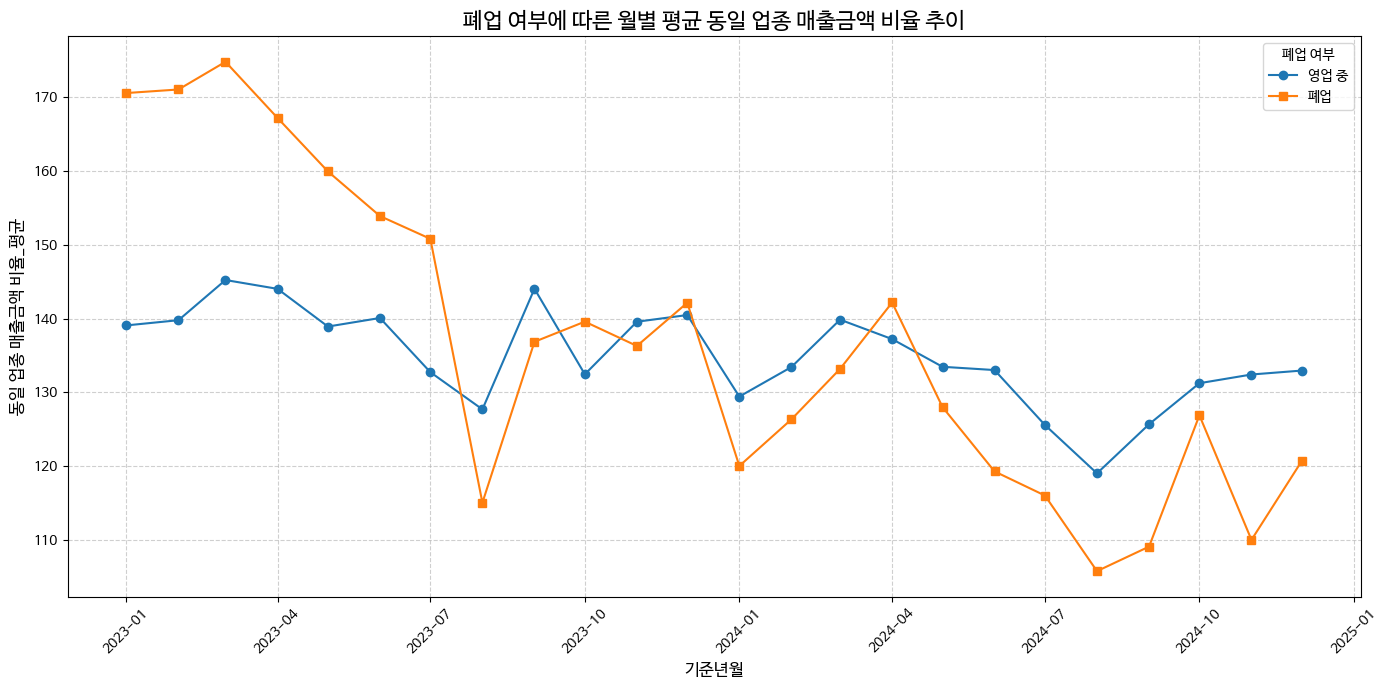

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 업종 매출금액 비율',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca()
plt.title('폐업 여부에 따른 월별 평균 동일 업종 매출금액 비율 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 업종 매출금액 비율_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 동일 업종 매출건수 비율 비교

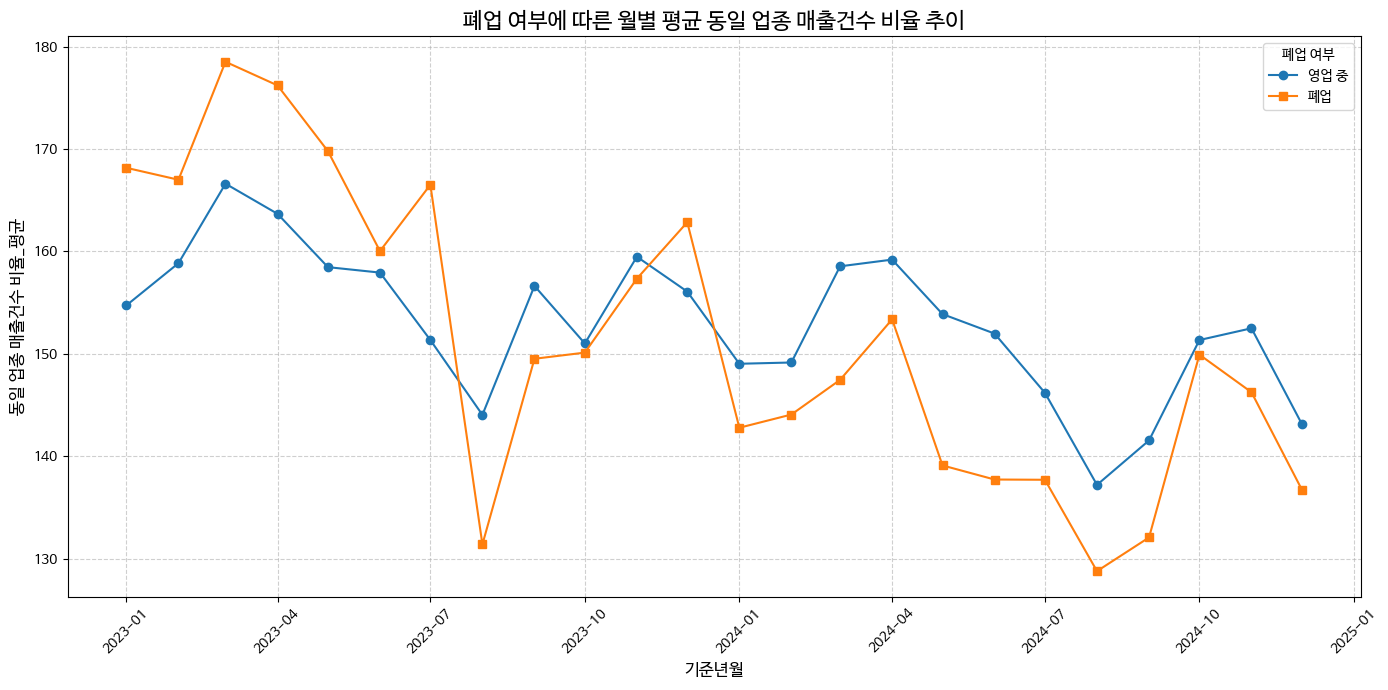

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 업종 매출건수 비율',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca()
plt.title('폐업 여부에 따른 월별 평균 동일 업종 매출건수 비율 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 업종 매출건수 비율_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 동일 업종 내 매출 순위 비율

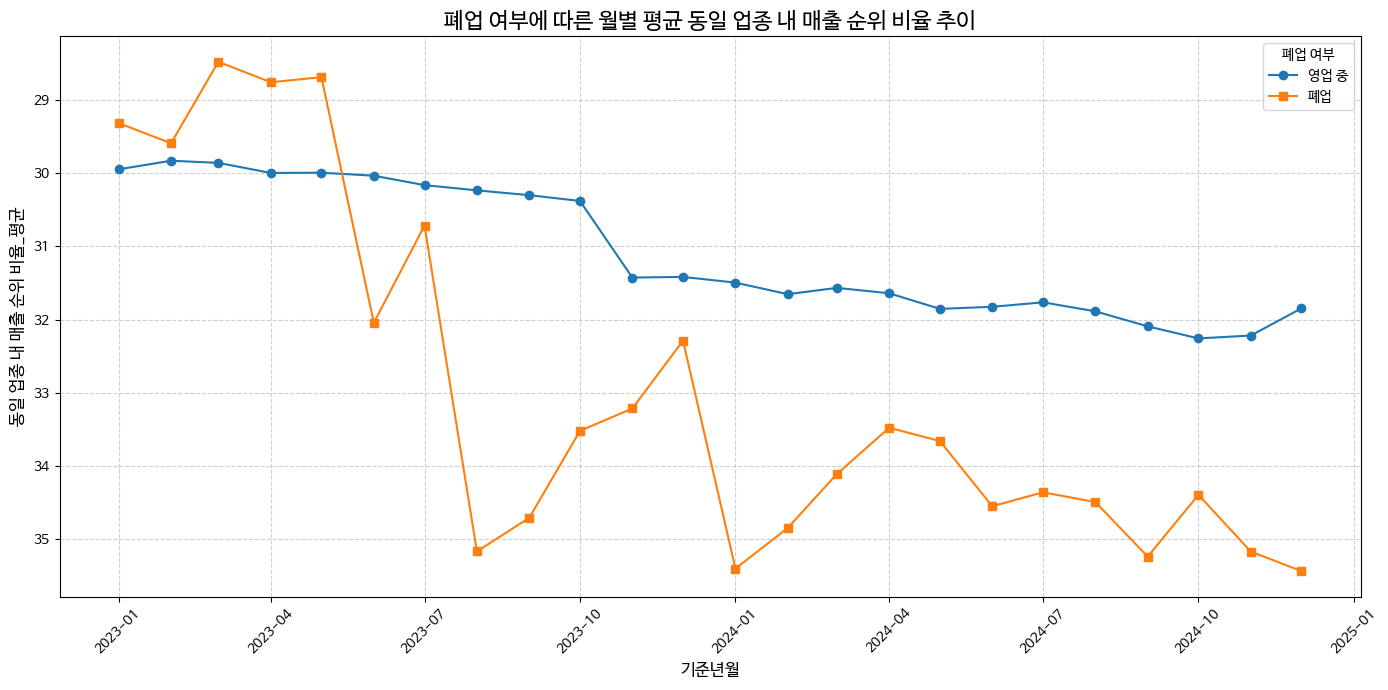

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 업종 내 매출 순위 비율',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 동일 업종 내 매출 순위 비율 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 업종 내 매출 순위 비율_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 동일 상권 내 매출 순위 비율

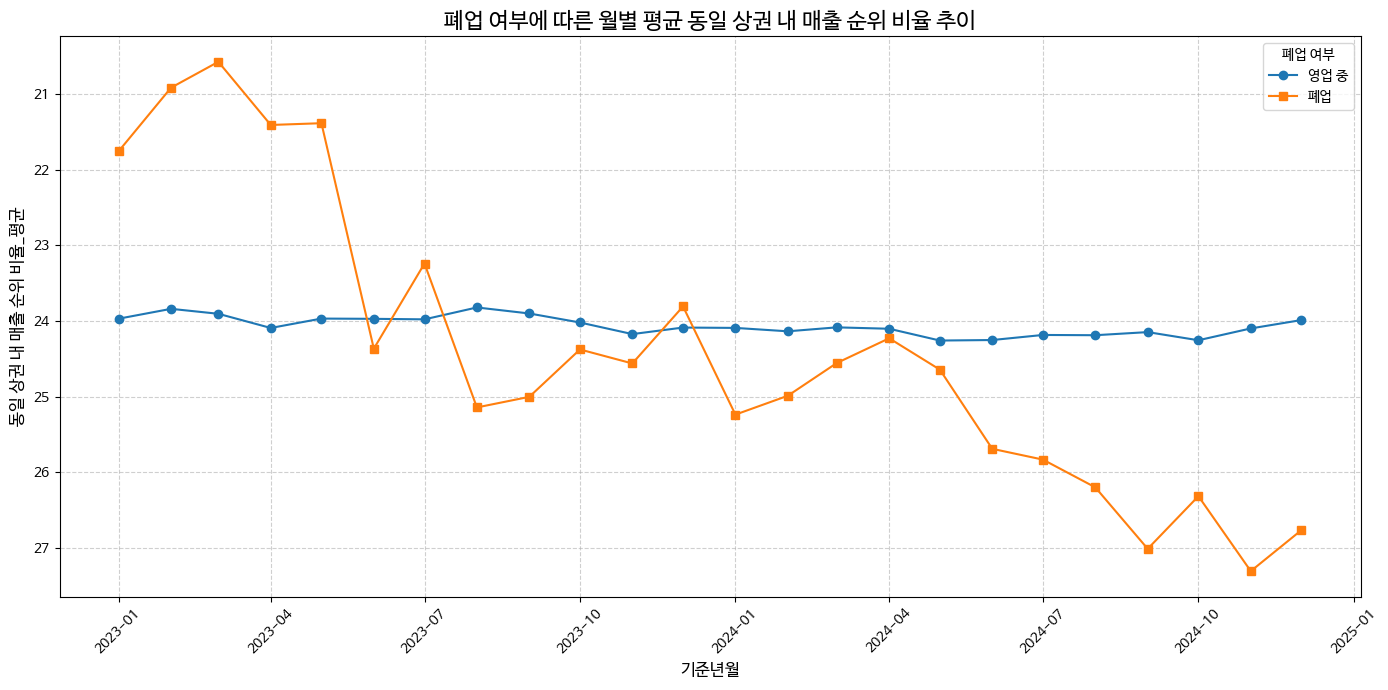

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 상권 내 매출 순위 비율',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')

plt.gca().invert_yaxis()
plt.title('폐업 여부에 따른 월별 평균 동일 상권 내 매출 순위 비율 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 상권 내 매출 순위 비율_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 동일 업종 내 해지 가맹점 비중

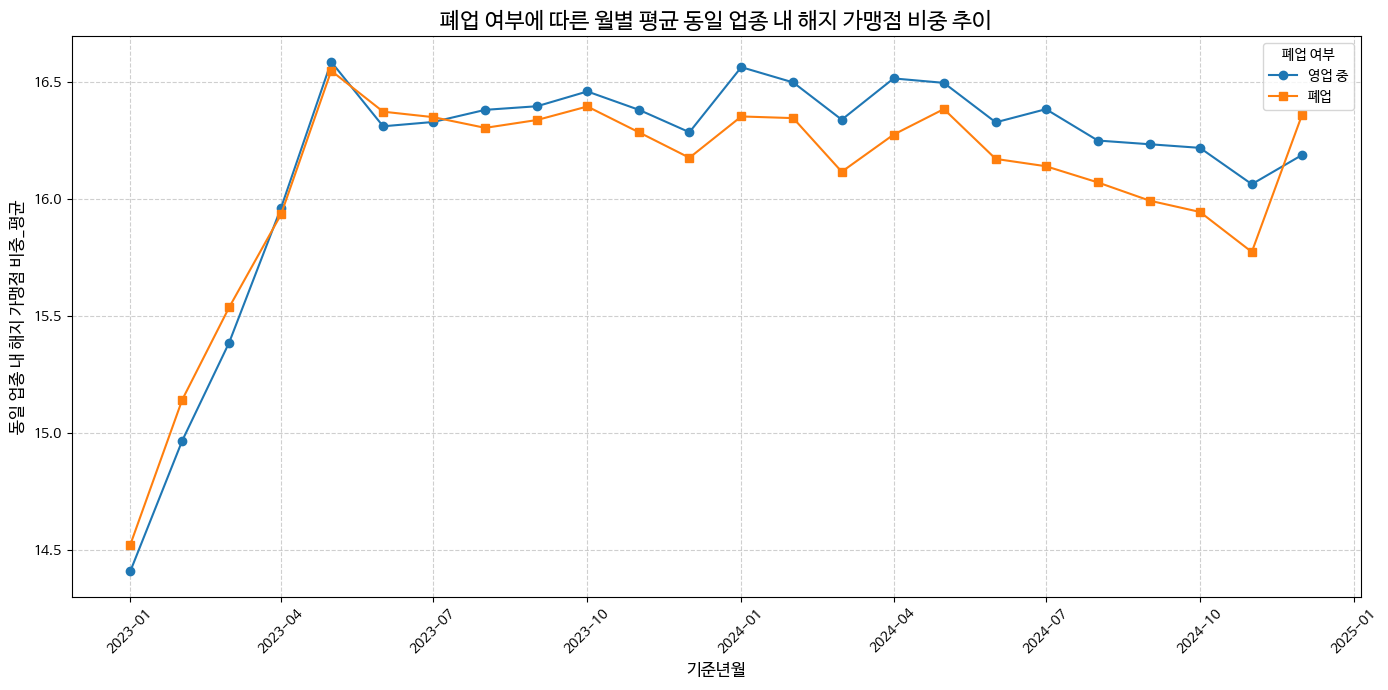

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 업종 내 해지 가맹점 비중',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')


plt.title('폐업 여부에 따른 월별 평균 동일 업종 내 해지 가맹점 비중 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 업종 내 해지 가맹점 비중_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 동일 상권 내 해지 가맹점 비중

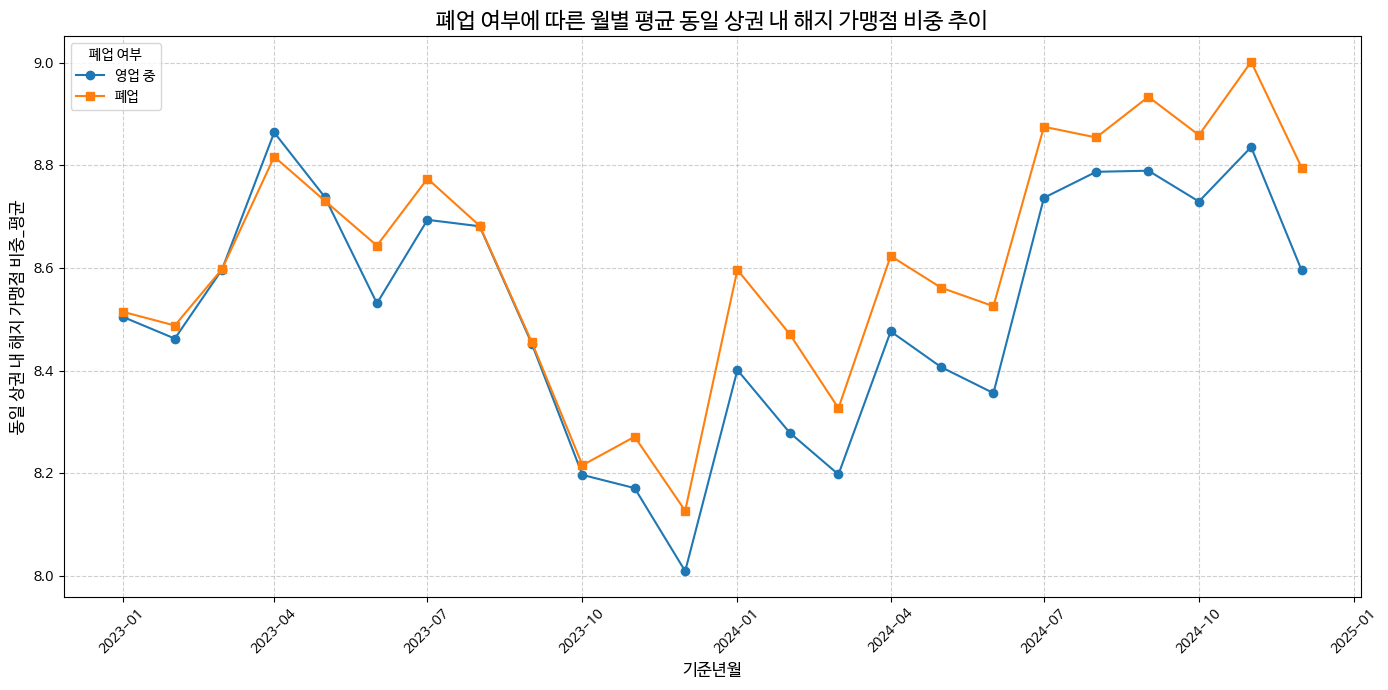

In [ ]:
monthly_avg_sales = merged_1and2.pivot_table(
    index='기준년월',
    columns='폐업여부',
    values='동일 상권 내 해지 가맹점 비중',
    aggfunc='mean',
    fill_value=np.nan
)
monthly_avg_sales.columns = ['영업중', '폐업']

plt.figure(figsize=(14, 7))

# 선 그래프로 영업 중인 가게와 폐업한 가게의 추세를 시각화
plt.plot(monthly_avg_sales.index, monthly_avg_sales['영업중'], label='영업 중', marker='o')
plt.plot(monthly_avg_sales.index, monthly_avg_sales['폐업'], label='폐업', marker='s')


plt.title('폐업 여부에 따른 월별 평균 동일 상권 내 해지 가맹점 비중 추이', fontsize=16)
plt.xlabel('기준년월', fontsize=12)
plt.ylabel('동일 상권 내 해지 가맹점 비중_평균', fontsize=12)
plt.legend(title='폐업 여부')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Dataset3 : 가맹점 월별 이용 고객 정보
  데이터 이름: store_customer

In [ ]:
# 데이터 확인
store_customer.head()

,가맹점구분번호,기준년월,남성 20대이하 고객 비중,남성 30대 고객 비중,남성 40대 고객 비중,남성 50대 고객 비중,남성 60대이상 고객 비중,여성 20대이하 고객 비중,여성 30대 고객 비중,여성 40대 고객 비중,여성 50대 고객 비중,여성 60대이상 고객 비중,재방문 고객 비중,신규 고객 비중,거주 이용 고객 비율,직장 이용 고객 비율,유동인구 이용 고객 비율
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [ ]:
# 데이터 요약 정보
store_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   가맹점구분번호         86590 non-null  object 
 1   기준년월            86590 non-null  int64  
 2   남성 20대이하 고객 비중  86590 non-null  float64
 3   남성 30대 고객 비중    86590 non-null  float64
 4   남성 40대 고객 비중    86590 non-null  float64
 5   남성 50대 고객 비중    86590 non-null  float64
 6   남성 60대이상 고객 비중  86590 non-null  float64
 7   여성 20대이하 고객 비중  86590 non-null  float64
 8   여성 30대 고객 비중    86590 non-null  float64
 9   여성 40대 고객 비중    86590 non-null  float64
 10  여성 50대 고객 비중    86590 non-null  float64
 11  여성 60대이상 고객 비중  86590 non-null  float64
 12  재방문 고객 비중       86590 non-null  float64
 13  신규 고객 비중        86590 non-null  float64
 14  거주 이용 고객 비율     86590 non-null  float64
 15  직장 이용 고객 비율     86590 non-null  float64
 16  유동인구 이용 고객 비율   86590 non-null  float64
dtypes: float64(15), int64(1), objec

##(전처리) -999999.9를 NaN으로

In [ ]:
# -999999.9(정보 없음) -> 결측치로(NaN) 바꿈
store_customer.replace(-999999.9, np.nan, inplace=True)
store_customer.isnull().sum()

,0
가맹점구분번호,0
기준년월,0
남성 20대이하 고객 비중,2004
남성 30대 고객 비중,2004
남성 40대 고객 비중,2004
남성 50대 고객 비중,2004
남성 60대이상 고객 비중,2004
여성 20대이하 고객 비중,2004
여성 30대 고객 비중,2004
여성 40대 고객 비중,2004


- 남성, 여성 20대 이하 ~ 60대 이상 고객 비중 결측값
-> 2004로 개수가 똑같음

- 재방문, 신규 고객 비중 결측값 -> 1643으로 개수 똑같음

- 거주, 직장, 유동인구 이용 고객 비율 결측값 -> 7327로 개수 똑같음



## (전처리) 기준년월 datetime형으로 변환

In [ ]:
# 연월 -> datetime 형식으로 날짜 변환하기
store_customer["기준년월"] = pd.to_datetime(store_customer["기준년월"], format = "%Y%m")

##(전처리)결측치 대체

In [ ]:
# 가맹점구분번호, 기준년월로 정렬
store_customer.sort_values(by=['가맹점구분번호', '기준년월'], inplace=True)

customer_ratio_cols = [
    "남성 20대이하 고객 비중",
    "남성 30대 고객 비중",
    "남성 40대 고객 비중",
    "남성 50대 고객 비중",
    "남성 60대이상 고객 비중",
    "여성 20대이하 고객 비중",
    "여성 30대 고객 비중",
    "여성 40대 고객 비중",
    "여성 50대 고객 비중",
    "여성 60대이상 고객 비중",
    "재방문 고객 비중",
    "신규 고객 비중",
    "거주 이용 고객 비율",
    "직장 이용 고객 비율",
    "유동인구 이용 고객 비율"
]

for col in customer_ratio_cols:
    # 1단계: 가맹점별 최빈값으로 결측치 채우기.
    mode_by_group = store_customer.groupby('가맹점구분번호')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    store_customer[col] = store_customer[col].fillna(mode_by_group)

    # 2단계: 그룹별 최빈값으로 채워지지 않은 결측치를 전체 데이터의 최빈값으로 채우기
    global_mode = store_customer[col].mode()
    # 전체 최빈값이 존재하는 경우에만 결측치를 채웁니다.
    if not global_mode.empty:
        store_customer[col] = store_customer[col].fillna(global_mode[0])

## 전체 변수간의 상관관계 분석


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


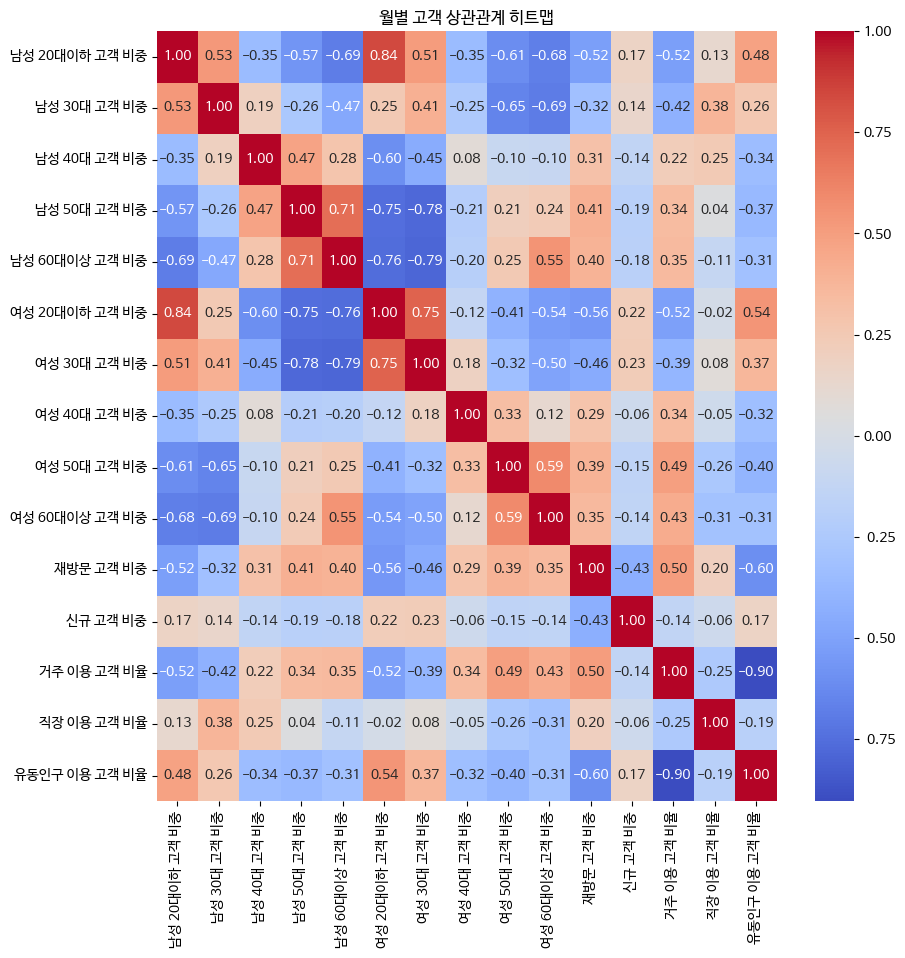

In [ ]:
# 전체 변수간의 상관관계 분석

# 원하는 열만 선택
selected_columns_sc = ['남성 20대이하 고객 비중',	'남성 30대 고객 비중',	'남성 40대 고객 비중',	'남성 50대 고객 비중',	'남성 60대이상 고객 비중',
                       '여성 20대이하 고객 비중',	'여성 30대 고객 비중',	'여성 40대 고객 비중',	'여성 50대 고객 비중',	'여성 60대이상 고객 비중',
                       '재방문 고객 비중',	'신규 고객 비중',	'거주 이용 고객 비율',	'직장 이용 고객 비율',	'유동인구 이용 고객 비율']
store_customer_selected = store_customer[selected_columns_sc]

# 상관관계 계산
correlation_matrix_sc = store_customer_selected.corr()

# 히트맵 시각화
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix_sc.corr(), annot=True, cmap = 'coolwarm', fmt=".2f")
plt.title("월별 고객 상관관계 히트맵")
plt.show()

- 1020남 많이 오면 1020여 많이 옴 (비례)
- 1020남 많이 오면 60남/60여 안옴 (반비례)

- 30남 많이오면 여60 많이 안옴 (반비례)

- 50, 60 남성 많이 오면 1020,30 여성 안옴 (반비례)
- 1020 여 많이 오면 30여 많이 옴 (비례)
- 재방문 고객 비중이랑 유동인구 이용 고객 비율 반비례 (반비례)

## 월별 고객 비율 비교

시즌, 계절별 고객층의 변화가 있는지 확인

- 전체 컬럼 다 비교 했을때 재방문 고객 비중이 너무 높아서, 남성&여성과 신규&재방문으로 나눴음

- 거주, 직장, 유동인구는 비율이라 따로 만듦

### 성별 및 연령대별

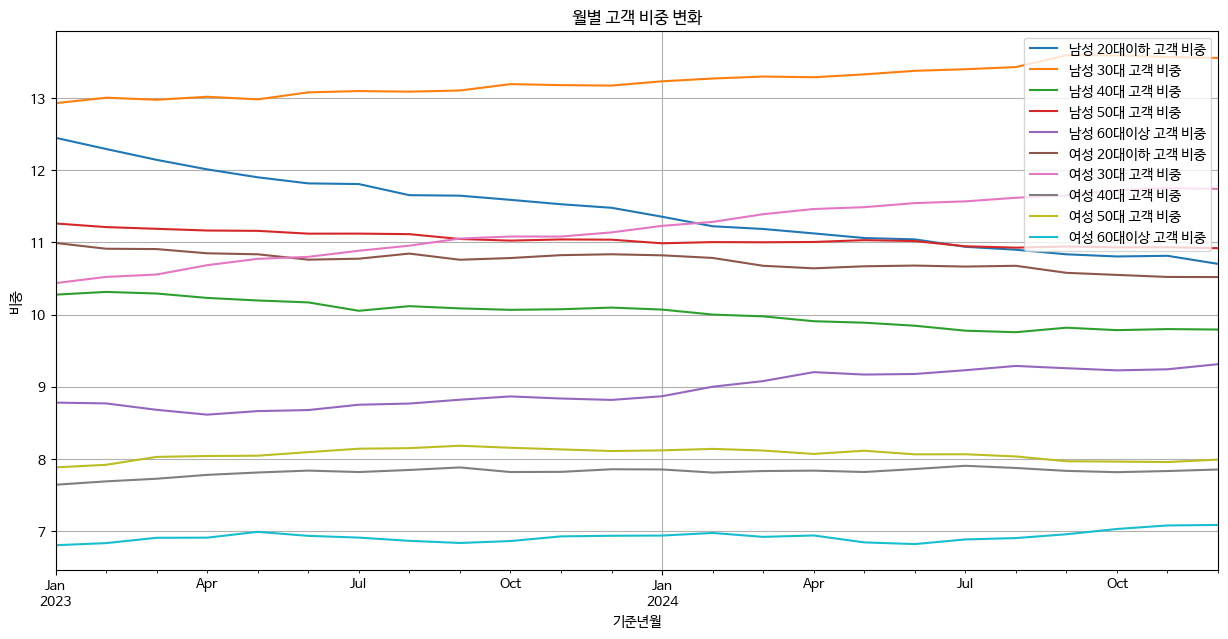

In [ ]:
# 모든 연령대 남성 + 여성 고객 비중 비교
selected_columns_1 =  store_customer[["기준년월"]+ ["남성 20대이하 고객 비중"]+	['남성 30대 고객 비중']+['남성 40대 고객 비중']+['남성 50대 고객 비중']+['남성 60대이상 고객 비중']+
                       ['여성 20대이하 고객 비중']+['여성 30대 고객 비중']+['여성 40대 고객 비중']	+['여성 50대 고객 비중']+['여성 60대이상 고객 비중']]
monthly_avg_1 = selected_columns_1.groupby("기준년월").mean()
plt.figure(figsize=(15,7))
monthly_avg_1.plot(ax=plt.gca())
plt.title("월별 고객 비중 변화")
plt.xlabel('기준년월')
plt.ylabel('비중')
plt.grid(True)
plt.show()



유지: 여성20, 여성60, 여성50, 여성40, 남성50

상승: 남성60, 남성30(top1)

감소: 남성40, 남성20(top2, 급격한 감소), 여성30(top3)

top3 안에 드는 남성20의 급격한 감소 원인을 알아볼 필요가 있다

### 재방문 및 신규고객

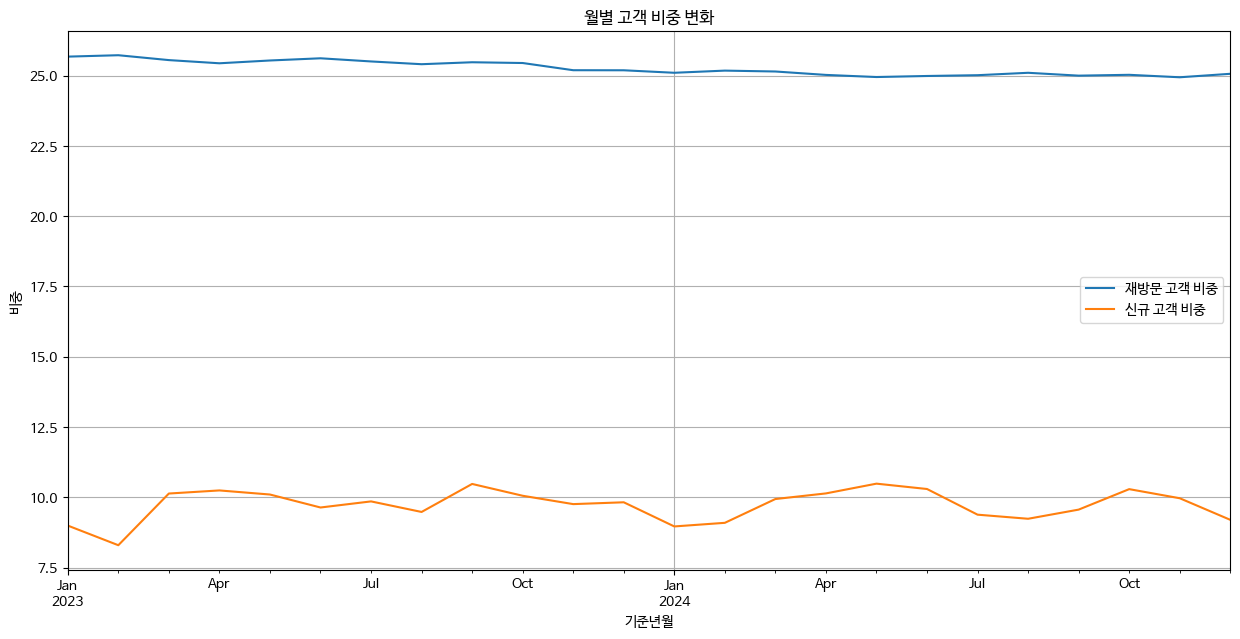

In [ ]:
# '재방문 고객 비중'+'신규 고객 비중'
selected_columns_2 =  store_customer[["기준년월"]+ ['재방문 고객 비중']+['신규 고객 비중']]
monthly_avg_2 = selected_columns_2.groupby("기준년월").mean()

# 시각화
plt.figure(figsize=(15,7))
monthly_avg_2.plot(ax=plt.gca())
plt.title("월별 고객 비중 변화")
plt.xlabel('기준년월')
plt.ylabel('비중')
plt.grid(True)
plt.show()

- 재방문 고객 비중이 큰 변화를 보이지 않으면서 압도적으로 높았고, 신규 고객 비중은 값이 매우 낮지만 규칙성이 보였다.

- 신규: 10월 이후에 감소 추세, 1-2월 최저, 3월부터 상승세이고, 특히 2023년 3월이 전체 최저점이다.

- 이러한 신규의 규칙성의 원인을 찾아야 한다. 상권?

### 거주, 직장, 및 유동인구

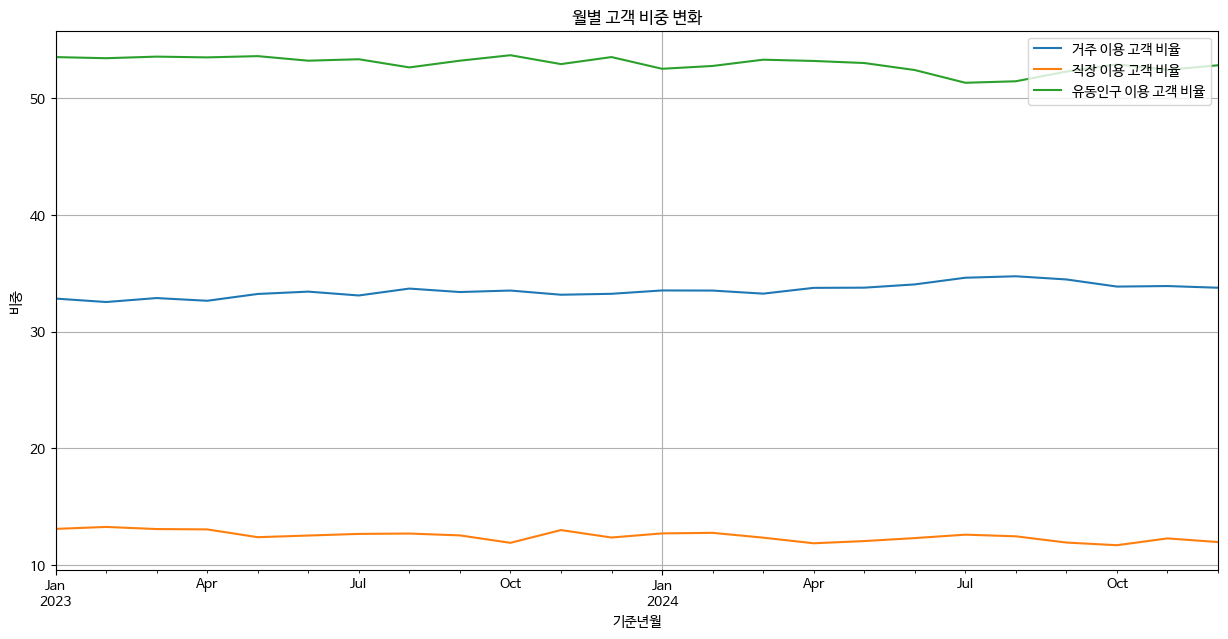

In [ ]:
# 거주, 직장, 유동인구 이용 고객 비율
selected_columns_3 =  store_customer[["기준년월"]+['거주 이용 고객 비율']+['직장 이용 고객 비율']+['유동인구 이용 고객 비율']]
monthly_avg_3 = selected_columns_3.groupby("기준년월").mean()

# 시각화
plt.figure(figsize=(15,7))
monthly_avg_3.plot(ax=plt.gca())
plt.title("월별 고객 비중 변화")
plt.xlabel('기준년월')
plt.ylabel('비중')
plt.grid(True)
plt.show()

- 유동인구 > 거주 > 직장 순으로 유동인구 이용 고객 비율이 압도적으로 높음을 알 수 있다.

- 반면에 직장 이용 고객 비율은 매우 낮아서 주변에 직장이 많은 지역이 없는 건지 확인이 필요하다.

### 혹시 상권별로 유동인구가 동일한지?

###

# Dataset1 + Dataset2 + Dataset3

In [ ]:
# 데이터1의 필요한 컬럼만
store_info_del = ['가맹점구분번호',	'가맹점주소',	'업종',	'상권',	'개설일',	'폐업일']
store_info_sel = store_info[store_info_del]

# 1+2+3
merged_1and2 = pd.merge(store_info_sel, store_sales, on="가맹점구분번호", how="outer")
merged_1and2and3 = pd.merge(merged_1and2, store_customer, on=("가맹점구분번호","기준년월"), how="outer")


## 결측치 있는 컬럼의 컬측 분포

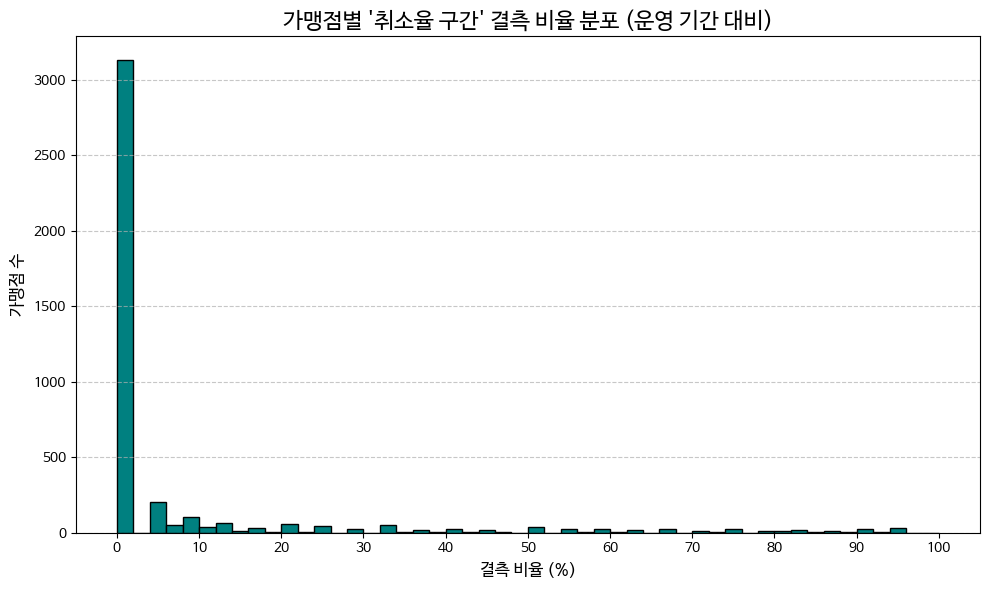

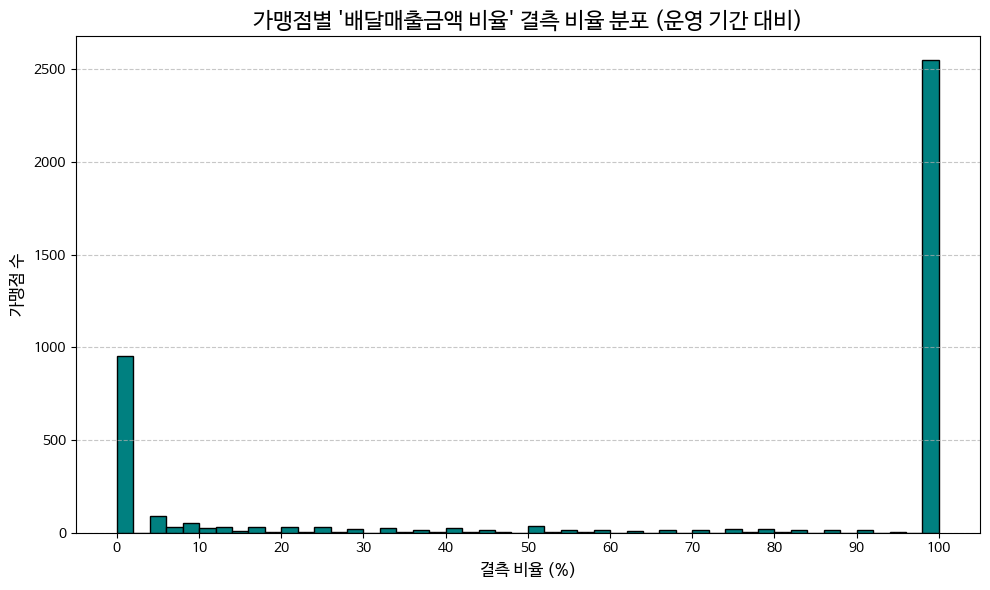

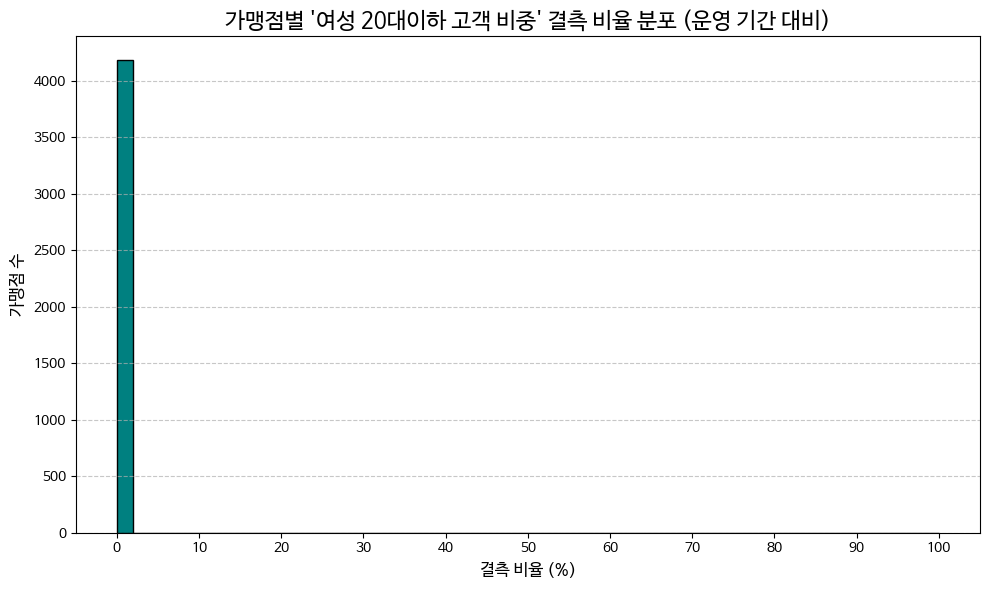

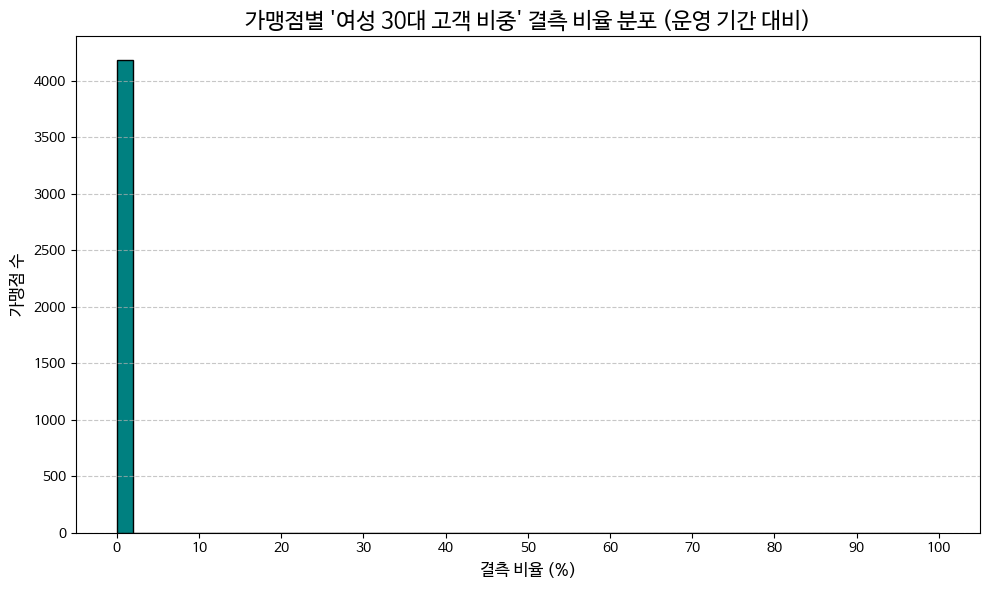

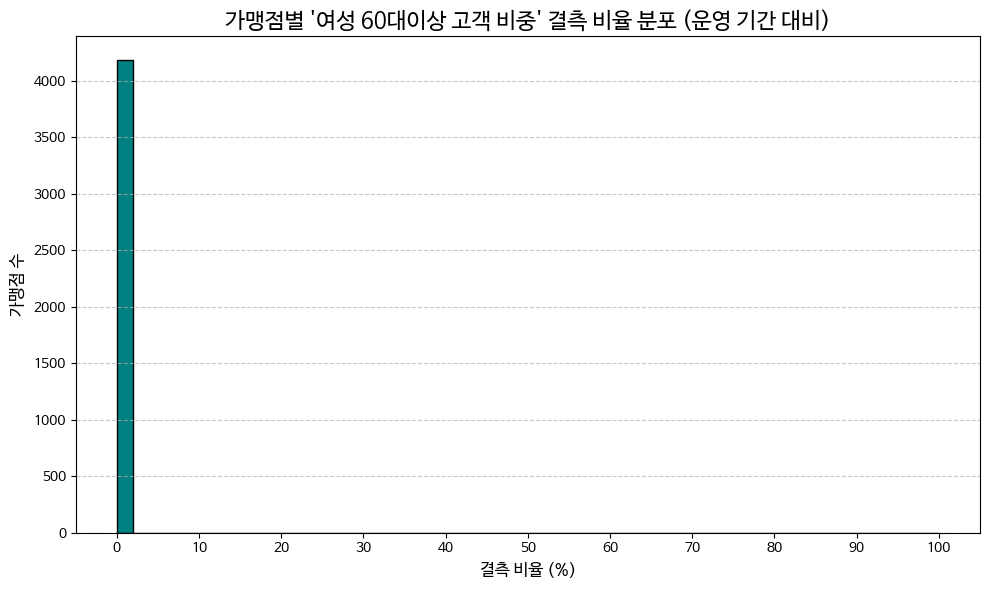

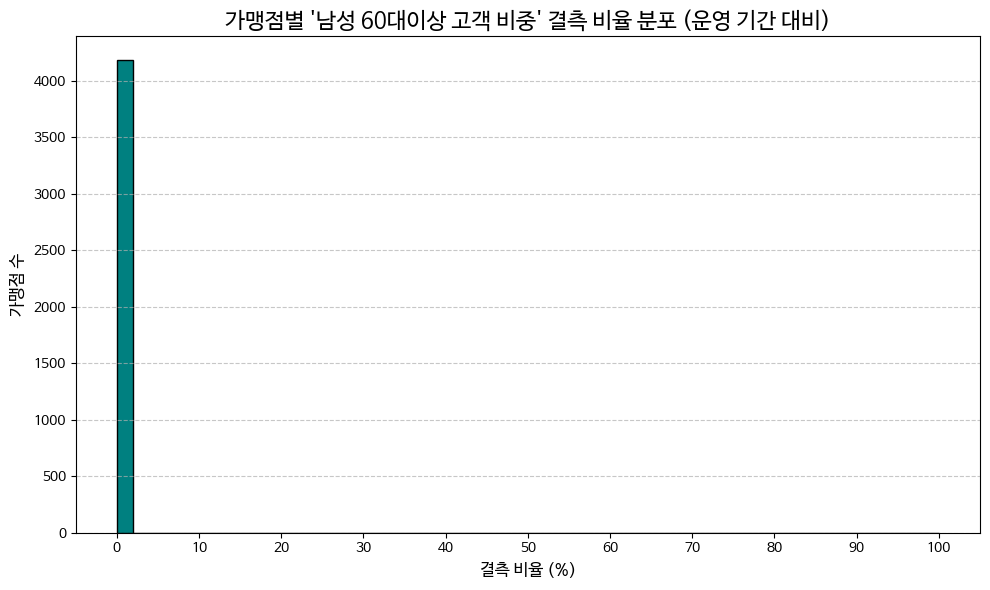

In [ ]:
# 1. 분석할 컬럼 리스트 정의
# '취소율 구간'을 포함하여 총 6가지 컬럼의 결측 분포를 확인할 수 있습니다.
target_columns = [
    "취소율 구간",
    "배달매출금액 비율",
    "여성 20대이하 고객 비중",
    "여성 30대 고객 비중",
    "여성 60대이상 고객 비중",
    "남성 60대이상 고객 비중"
]

# 2. 전체 기준년월 수 (총 운영 개월 수)는 모든 컬럼에 대해 동일합니다.
total_cnt = merged_1and2and3.groupby("가맹점구분번호")["기준년월"].nunique().reset_index(name="전체 기준년월 수")

# 3. 각 컬럼별로 루프를 돌며 결측 비율 계산 및 시각화 반복
for col_name in target_columns:

    # 3-1. 현재 컬럼의 결측 기준년월 수 계산
    missing_cnt = merged_1and2and3[merged_1and2and3[col_name].isna()] \
        .groupby("가맹점구분번호")["기준년월"].nunique().reset_index(name="결측 기준년월 수")

    # 3-2. 데이터 병합 및 결측이 없던 가게는 0으로 처리
    result = total_cnt.merge(missing_cnt, on="가맹점구분번호", how="left").fillna(0)

    # 3-3. 결측 비율(%) 계산
    result["결측 비율(%)"] = (result["결측 기준년월 수"] / result["전체 기준년월 수"]) * 100

    # 3-4. 시각화: 히스토그램
    plt.figure(figsize=(10, 6))

    plt.hist(
        result["결측 비율(%)"],
        bins=50,
        color="teal",
        edgecolor="black",
        range=(0, 100)
    )

    title_text = f"가맹점별 '{col_name}' 결측 비율 분포 (운영 기간 대비)"
    plt.title(title_text, fontsize=16)
    plt.xlabel("결측 비율 (%)", fontsize=12)
    plt.ylabel("가맹점 수", fontsize=12)
    plt.xticks(np.arange(0, 101, 10))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # 그래프 요소가 겹치지 않도록 조정
    plt.show()



- 가맹점별로 결측치의 비율을 보았을 때, '배달매출금액 비율'의 결측치의 경우
더 많은 가맹점(약 2,500개 이상)이 모든 기간에 배달매출금액 데이터가 결측치인 상태이다
  - 배달 매출이 발생하지 않은 경우로 0으로 변환해 배달매출이 없다고 해석